# Coloración de Grafos
## MA2015 - Diseño de Algoritmos Bioinspirados

Viviana Carrizales Luna (A01286191) & Steffany Mishell Lara Muy (A00838589)
*Instituto Tecnológico y de Estudios Superiores de Monterrey (ITESM)*

**Resumen**
El presente proyecto tiene como finalidad desarrollar un algoritmo bioinspirado genético para la solución del problema de coloración de grafos. El objetivo final será poder colorear los nodos con la cantidad mínima de colores, de forma que los nodos adyacentes no posean el mismo color.

### 1. Importación de Librerías y Configuración Inicial

In [3]:
import pulp, random
import matplotlib.pyplot as plt
import time

In [4]:
V = list(range(1, 20))

# Aristas (basado en la imagen del grafo)
E = [
(1,2),(1,4),(1,16),
(2,1),(2,4),(2,5),(2,6),(2,7),(2,3),
(3,2),(3,7),(3,11),(3,19),
(4,1),(4,2),(4,5),(4,9),(4,8),
(5,2),(5,4),(5,6),(5,9),(5,10),
(6,2),(6,5),(6,7),(6,11),(6,14),
(7,2),(7,3),(7,6),(7,11),
(8,4),(8,9),(8,12),(8,16),
(9,4),(9,5),(9,8),(9,10),(9,12),(9,13),(9,15),
(10,5),(10,9),(10,13),(10,14),
(11,3),(11,7),(11,6),(11,14),(11,19),
(12,8),(12,9),(12,16),(12,15),
(13,9),(13,10),(13,14),(13,15),(13,17),(13,18),
(14,6),(14,11),(14,10),(14,13),(14,18),(14,19),
(15,12),(15,9),(15,13),(15,17),(15,16),
(16,1),(16,8),(16,12),(16,15),(16,17),
(17,16),(17,15),(17,13),(17,18),(17,19),
(18,17),(18,13),(18,14),(18,19),
(19,17),(19,18),(19,14),(19,11),(19,3)
]

NUM_NODOS = len(V)
MAX_COLORES = NUM_NODOS  # Peor caso: cada nodo un color diferente


### 2. Solución Exacta

In [5]:
def metodo_matematico():
    """
    Busca el MÍNIMO número de colores usando programación lineal entera
    Estrategia: probar desde 1 color hasta encontrar solución factible
    """
    
    print("MÉTODO MATEMÁTICO (PuLP)")
    
    
    inicio = time.time()
    
    # Probar desde 1 color hasta encontrar solución
    for num_colores in range(1, MAX_COLORES + 1):
        print(f"Probando con {num_colores} colores...", end=" ")
        
        # Crear el problema
        prob = pulp.LpProblem("Coloracion_Grafos", pulp.LpMinimize)
        
        # Variables: x[i][c] = 1 si nodo i tiene color c
        colores = range(1, num_colores + 1)
        x = {}
        for i in V:
            for c in colores:
                x[i, c] = pulp.LpVariable(f"x_{i}_{c}", cat='Binary')
        
        # Función objetivo: constante (solo buscamos factibilidad)
        prob += 0
        
        # Restricción 1: cada nodo tiene exactamente un color
        for i in V:
            prob += pulp.lpSum(x[i, c] for c in colores) == 1
        
        # Restricción 2: nodos adyacentes no pueden tener el mismo color
        for (i, j) in E:
            for c in colores:
                prob += x[i, c] + x[j, c] <= 1
        
        # Resolver
        prob.solve(pulp.PULP_CBC_CMD(msg=0))
        
        if prob.status == pulp.LpStatusOptimal:
            print("Funcionaaaaa!!!!!!")
            
            fin = time.time()
            tiempo = fin - inicio
            
            # Extraer solución
            solucion = {}
            for i in V:
                for c in colores:
                    if pulp.value(x[i, c]) == 1:
                        solucion[i] = c
            
            print(f"\n*** NÚMERO COLORES ENCONTRADO: {num_colores} ***")
            print(f"Tiempo total: {tiempo:.4f} segundos")
            print(f"Asignación: {solucion}")
            
            return solucion, num_colores, tiempo
        else:
            print("No factible")
    
    return None, MAX_COLORES, time.time() - inicio



## 3. Algoritmo Genético

In [6]:
"""
PARÁMETROS DEL ALGORITMO GENÉTICO:
- Tipo de cromosoma: Lista de enteros (cada gen = color del nodo)
- Longitud: 19 genes (uno por nodo)
- Tamaño población: 50 individuos
- Inicialización: Aleatoria, empezando con muchos colores
- Criterio infactibilidad: Contar conflictos (aristas mismo color)
- Criterio de paro: 200 generaciones o fitness = 0
- Función fitness: Penaliza conflictos + número de colores usados
- Selección: Torneo de tamaño 3
- Probabilidad cruce: 0.8
- Puntos de cruce: 1 punto
- Probabilidad mutación: 0.15
- Reemplazo: Generacional con elitismo
"""

TAM_POBLACION = 80
GENERACIONES = 150 #porq si
PROB_CRUCE = 0.8
PROB_MUTACION = 0.2
TAM_TORNEO = 3

def crear_individuo(num_colores):
    """Crea un cromosoma aleatorio con num_colores colores disponibles"""
    return [random.randint(1, num_colores) for _ in range(NUM_NODOS)]

def contar_conflictos(cromosoma):
    """Cuenta cuántas aristas tienen nodos del mismo color"""
    conflictos = 0
    for (i, j) in E:
        if cromosoma[i-1] == cromosoma[j-1]:
            conflictos += 1
    return conflictos

def contar_colores(cromosoma):
    """Cuenta cuántos colores diferentes se usan"""
    return len(set(cromosoma))

def calcular_fitness(cromosoma):
    """
    Fitness combinado:
    - Penalización alta por conflictos (x1000)
    - Penalización baja por número de colores
    Menor fitness = mejor solución
    """
    conflictos = contar_conflictos(cromosoma)
    colores = contar_colores(cromosoma)
    return conflictos * 1000 + colores

def seleccion_torneo(poblacion, fitnesses):
    """Selección por torneo"""
    participantes = random.sample(range(len(poblacion)), TAM_TORNEO)
    mejor = min(participantes, key=lambda i: fitnesses[i])
    return poblacion[mejor].copy()

def cruce(padre1, padre2):
    """Cruce de un punto"""
    if random.random() < PROB_CRUCE:
        punto = random.randint(1, NUM_NODOS - 1)
        hijo1 = padre1[:punto] + padre2[punto:]
        hijo2 = padre2[:punto] + padre1[punto:]
        return hijo1, hijo2
    return padre1.copy(), padre2.copy()

def mutacion(cromosoma, num_colores):
    """Mutación: cambiar color de un gen aleatorio"""
    for i in range(len(cromosoma)):
        if random.random() < PROB_MUTACION:
            cromosoma[i] = random.randint(1, num_colores)
    return cromosoma

def reducir_colores(cromosoma):
    """
    Renumera los colores para eliminar huecos
    Ej: [1,3,5,3,1] -> [1,2,3,2,1]
    """
    colores_usados = sorted(set(cromosoma))
    mapeo = {c: i+1 for i, c in enumerate(colores_usados)}
    return [mapeo[c] for c in cromosoma]


In [7]:

def algoritmo_genetico():
    """
    Ejecuta el algoritmo genético para encontrar el número cromático mínimo
    Estrategia: empezar con muchos colores e ir reduciendo progresivamente
    """
    
    print("ALGORITMO GENÉTICO")
    
    
    inicio = time.time()
    
    # Guardar historial
    historial_mejor = []
    historial_colores = []
    
    mejor_solucion_global = None
    mejor_colores_global = NUM_NODOS
    
    # ESTRATEGIA: Probar con cada número de colores, de mayor a menor
    # Empezamos con 10 colores (suficiente para este grafo)
    
    for num_colores_actual in range(10, 0, -1):
        print(f"\nProbando con {num_colores_actual} colores...")
        
        # Más generaciones para números pequeños de colores (más difícil)
        gen_actuales = GENERACIONES if num_colores_actual > 5 else GENERACIONES * 3
        
        # Inicialización de población para este número de colores
        poblacion = [crear_individuo(num_colores_actual) for _ in range(TAM_POBLACION)]
        
        mejor_individuo = None
        mejor_conflictos = float('inf')
        
        # Correr generaciones para este número de colores
        for gen in range(gen_actuales):
            fitnesses = [contar_conflictos(ind) for ind in poblacion]
            
            # Actualizar mejor
            idx_mejor = fitnesses.index(min(fitnesses))
            if fitnesses[idx_mejor] < mejor_conflictos:
                mejor_conflictos = fitnesses[idx_mejor]
                mejor_individuo = poblacion[idx_mejor].copy()
            
            # Guardar historial
            historial_mejor.append(mejor_conflictos)
            historial_colores.append(num_colores_actual)
            
            # Si encontramos solución sin conflictos, éxito!
            if mejor_conflictos == 0:
                break
            
            # Crear nueva población
            nueva_poblacion = []
            
            # Elitismo
            nueva_poblacion.append(mejor_individuo.copy())
            
            while len(nueva_poblacion) < TAM_POBLACION:
                padre1 = seleccion_torneo(poblacion, fitnesses)
                padre2 = seleccion_torneo(poblacion, fitnesses)
                
                hijo1, hijo2 = cruce(padre1, padre2)
                
                hijo1 = mutacion(hijo1, num_colores_actual)
                hijo2 = mutacion(hijo2, num_colores_actual)
                
                nueva_poblacion.append(hijo1)
                if len(nueva_poblacion) < TAM_POBLACION:
                    nueva_poblacion.append(hijo2)
            
            poblacion = nueva_poblacion
        
        # Verificar si encontramos solución válida con este número de colores
        if mejor_conflictos == 0:
            print(f" FUNCIONAAAAA, Conflictos=0")
            mejor_solucion_global = mejor_individuo.copy()
            mejor_colores_global = num_colores_actual
            # Seguir intentando con menos colores
        else:
            print(f"  No factible (mejor conflictos={mejor_conflictos})")
            # No se puede con menos colores, terminar
            break
    
    fin = time.time()
    tiempo = fin - inicio
    
    # Usar la mejor solución encontrada
    if mejor_solucion_global is not None:
        mejor_individuo = reducir_colores(mejor_solucion_global)
        solucion = {i+1: mejor_individuo[i] for i in range(NUM_NODOS)}
        num_colores = contar_colores(mejor_individuo)
        conflictos = 0
    else:
        solucion = {i+1: i+1 for i in range(NUM_NODOS)}
        num_colores = NUM_NODOS
        conflictos = 0
    
    print(f"\n*** NÚMERO COLORES ENCONTRADO: {num_colores} ***")
    print(f"Conflictos: {conflictos}")
    print(f"Tiempo: {tiempo:.4f} segundos")
    print(f"Asignación: {solucion}")
    
    return solucion, num_colores, tiempo, historial_mejor, historial_colores, conflictos



In [8]:
def ejemplitooo():
    """Muestra un ejemplo detallado del algoritmo genético"""
    
    print("Ejemplo ejecucion")
    
    
    print("\n1. CREAR POBLACIÓN INICIAL (3 individuos)")
    print("   (Empezamos con hasta 6 colores disponibles)")
    mini_pop = [crear_individuo(6) for _ in range(3)]
    for i, ind in enumerate(mini_pop):
        conf = contar_conflictos(ind)
        cols = contar_colores(ind)
        print(f"   Individuo {i+1}: {ind[:6]}... Conflictos={conf}, Colores={cols}")
    
    print("\n2. CALCULAR FITNESS")
    print("   Fitness = conflictos*1000 + colores")
    for i, ind in enumerate(mini_pop):
        fit = calcular_fitness(ind)
        print(f"   Individuo {i+1}: Fitness = {fit}")
    
    print("\n3. SELECCIÓN POR TORNEO (tamaño 3)")
    fitnesses = [calcular_fitness(ind) for ind in mini_pop]
    padre1 = seleccion_torneo(mini_pop, fitnesses)
    padre2 = seleccion_torneo(mini_pop, fitnesses)
    print(f"   Padre 1 seleccionado: {padre1[:6]}...")
    print(f"   Padre 2 seleccionado: {padre2[:6]}...")
    
    print("\n4. CRUCE DE UN PUNTO")
    punto = 10
    hijo = padre1[:punto] + padre2[punto:]
    print(f"   Punto de cruce: posición {punto}")
    print(f"   Hijo: {hijo[:6]}...")
    
    print("\n5. MUTACIÓN (prob=0.15 por gen)")
    hijo_original = hijo.copy()
    hijo = mutacion(hijo, 6)
    cambios = sum(1 for a, b in zip(hijo_original, hijo) if a != b)
    print(f"   Genes mutados: {cambios}")
    
    print("\n6. REDUCIR COLORES")
    print(f"   Antes: {hijo[:6]}... usa colores {sorted(set(hijo))}")
    hijo = reducir_colores(hijo)
    print(f"   Después: {hijo[:6]}... usa colores {sorted(set(hijo))}")
    
    print("\n7. EVALUAR NUEVO INDIVIDUO")
    print(f"   Conflictos: {contar_conflictos(hijo)}")
    print(f"   Colores usados: {contar_colores(hijo)}")
    print(f"   Fitness: {calcular_fitness(hijo)}")



### 4. Visualización

In [9]:
def graficar_resultados(hist_conflictos, hist_colores, t_mat, t_ag, col_mat, col_ag):
    """Genera gráficas de comparación"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Gráfica 1: Evolución de conflictos
    axes[0].plot(hist_conflictos, 'b-', linewidth=2)
    axes[0].set_xlabel('Generación')
    axes[0].set_ylabel('Conflictos')
    axes[0].set_title('Evolución de Conflictos (AG)')
    axes[0].grid(True)
    
    # Gráfica 2: Evolución de colores
    axes[1].plot(hist_colores, 'g-', linewidth=2)
    axes[1].set_xlabel('Generación')
    axes[1].set_ylabel('Número de colores')
    axes[1].set_title('Evolución de Colores Usados (AG)')
    axes[1].grid(True)
    
    # Gráfica 3: Comparación final
    metodos = ['Matemático\n(PuLP)', 'Algoritmo\nGenético']
    colores_final = [col_mat, col_ag]
    tiempos = [t_mat, t_ag]
    
    x = range(len(metodos))
    width = 0.35
    
    bars1 = axes[2].bar([i - width/2 for i in x], colores_final, width, label='Colores', color='steelblue')
    axes[2].set_ylabel('Número de colores')
    axes[2].set_title('Comparación de Métodos')
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(metodos)
    
    ax2 = axes[2].twinx()
    bars2 = ax2.bar([i + width/2 for i in x], tiempos, width, label='Tiempo', color='coral')
    ax2.set_ylabel('Tiempo (segundos)')
    
    # Etiquetas
    for bar, val in zip(bars1, colores_final):
        axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                    str(val), ha='center', fontsize=10)
    for bar, val in zip(bars2, tiempos):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{val:.3f}s', ha='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()



In [10]:

def imprimir_tabla(sol_mat, col_mat, t_mat, sol_ag, col_ag, t_ag, conf_ag):
    """Imprime tabla de comparación"""
    print("TABLA DE COMPARACIÓN DE RESULTADOS")
    print(f"{'Criterio':<30} {'Matemático':<15} {'Genético':<15}")
    print("-"*65)
    print(f"{'Número cromático (χ)':<30} {col_mat:<15} {col_ag:<15}")
    print(f"{'Conflictos':<30} {0:<15} {conf_ag:<15}")
    print(f"{'Tiempo (segundos)':<30} {t_mat:<15.4f} {t_ag:<15.4f}")
    print(f"{'Solución óptima':<30} {'Sí':<15} {'Sí' if conf_ag == 0 else 'No':<15}")

    
    print("ASIGNACIÓN DE COLORES POR NODO")
    print(f"{'Nodo':<8} {'Matemático':<15} {'Genético':<15}")
    for nodo in V:
        print(f"{nodo:<8} {sol_mat[nodo]:<15} {sol_ag[nodo]:<15}")


### * EJECUTAR *

PROBLEMA DE COLORACIÓN DE GRAFOS
Objetivo: Encontrar el MÍNIMO número de colores (χ)
Grafo: 19 nodos, 92 aristas
Ejemplo ejecucion

1. CREAR POBLACIÓN INICIAL (3 individuos)
   (Empezamos con hasta 6 colores disponibles)
   Individuo 1: [2, 4, 4, 1, 1, 6]... Conflictos=14, Colores=6
   Individuo 2: [1, 4, 5, 5, 1, 4]... Conflictos=18, Colores=6
   Individuo 3: [1, 1, 5, 1, 1, 6]... Conflictos=20, Colores=6

2. CALCULAR FITNESS
   Fitness = conflictos*1000 + colores
   Individuo 1: Fitness = 14006
   Individuo 2: Fitness = 18006
   Individuo 3: Fitness = 20006

3. SELECCIÓN POR TORNEO (tamaño 3)
   Padre 1 seleccionado: [2, 4, 4, 1, 1, 6]...
   Padre 2 seleccionado: [2, 4, 4, 1, 1, 6]...

4. CRUCE DE UN PUNTO
   Punto de cruce: posición 10
   Hijo: [2, 4, 4, 1, 1, 6]...

5. MUTACIÓN (prob=0.15 por gen)
   Genes mutados: 3

6. REDUCIR COLORES
   Antes: [2, 4, 4, 5, 1, 2]... usa colores [1, 2, 3, 4, 5, 6]
   Después: [2, 4, 4, 5, 1, 2]... usa colores [1, 2, 3, 4, 5, 6]

7. EVALUAR NUEVO I

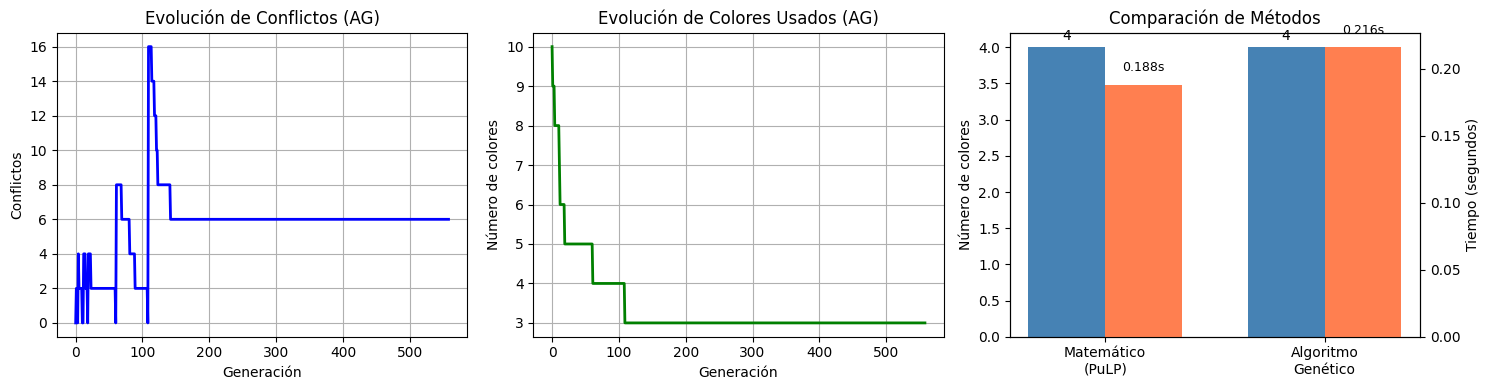

In [11]:
if __name__ == "__main__":
    print("PROBLEMA DE COLORACIÓN DE GRAFOS")
    print("Objetivo: Encontrar el MÍNIMO número de colores (χ)")
    print(f"Grafo: {NUM_NODOS} nodos, {len(E)} aristas")
    
    # Ejemplo paso a paso
    '''
    es para no hacerlo a mano pq si me daba mucha hueva jaja
    '''
    ejemplitooo()
    
    # Método matemático
    sol_mat, col_mat, t_mat = metodo_matematico()
    
    # Algoritmo genético
    sol_ag, col_ag, t_ag, hist_conf, hist_col, conf_ag = algoritmo_genetico()
    
    # Tabla de comparación
    imprimir_tabla(sol_mat, col_mat, t_mat, sol_ag, col_ag, t_ag, conf_ag)
    
    # Gráficas
    graficar_resultados(hist_conf, hist_col, t_mat, t_ag, col_mat, col_ag)

In [13]:
ejemplitooo()

Ejemplo ejecucion

1. CREAR POBLACIÓN INICIAL (3 individuos)
   (Empezamos con hasta 6 colores disponibles)
   Individuo 1: [4, 3, 5, 1, 5, 5]... Conflictos=14, Colores=6
   Individuo 2: [6, 3, 1, 6, 4, 4]... Conflictos=14, Colores=6
   Individuo 3: [3, 4, 4, 5, 1, 1]... Conflictos=18, Colores=6

2. CALCULAR FITNESS
   Fitness = conflictos*1000 + colores
   Individuo 1: Fitness = 14006
   Individuo 2: Fitness = 14006
   Individuo 3: Fitness = 18006

3. SELECCIÓN POR TORNEO (tamaño 3)
   Padre 1 seleccionado: [6, 3, 1, 6, 4, 4]...
   Padre 2 seleccionado: [4, 3, 5, 1, 5, 5]...

4. CRUCE DE UN PUNTO
   Punto de cruce: posición 10
   Hijo: [6, 3, 1, 6, 4, 4]...

5. MUTACIÓN (prob=0.15 por gen)
   Genes mutados: 0

6. REDUCIR COLORES
   Antes: [6, 3, 1, 6, 4, 4]... usa colores [1, 2, 3, 4, 6]
   Después: [5, 3, 1, 5, 4, 4]... usa colores [1, 2, 3, 4, 5]

7. EVALUAR NUEVO INDIVIDUO
   Conflictos: 16
   Colores usados: 5
   Fitness: 16005


PROBLEMA DE COLORACIÓN DE GRAFOS
Objetivo: Encontrar el MÍNIMO número de colores (χ)
Grafo: 19 nodos, 47 aristas

EJEMPLO PASO A PASO (UNA GENERACIÓN COMPLETA)

----------------------------------------------------------------------
PASO 1: CREAR POBLACIÓN INICIAL
----------------------------------------------------------------------
Parámetros: 3 individuos, 19 colores disponibles, 19 genes

Cada gen es un color aleatorio entre 1 y 4:

  Individuo 1:
    Generando genes: 4 1 9 8 8 5 4 18 3 19 14 2 1 3 7 8 17 1 18 
    Cromosoma completo: [4, 1, 9, 8, 8, 5, 4, 18, 3, 19, 14, 2, 1, 3, 7, 8, 17, 1, 18]

  Individuo 2:
    Generando genes: 7 18 14 8 15 19 9 1 6 14 11 9 5 7 11 4 3 13 4 
    Cromosoma completo: [7, 18, 14, 8, 15, 19, 9, 1, 6, 14, 11, 9, 5, 7, 11, 4, 3, 13, 4]

  Individuo 3:
    Generando genes: 12 12 9 2 15 18 4 13 3 18 10 12 19 7 3 2 8 10 3 
    Cromosoma completo: [12, 12, 9, 2, 15, 18, 4, 13, 3, 18, 10, 12, 19, 7, 3, 2, 8, 10, 3]

----------------------------------------

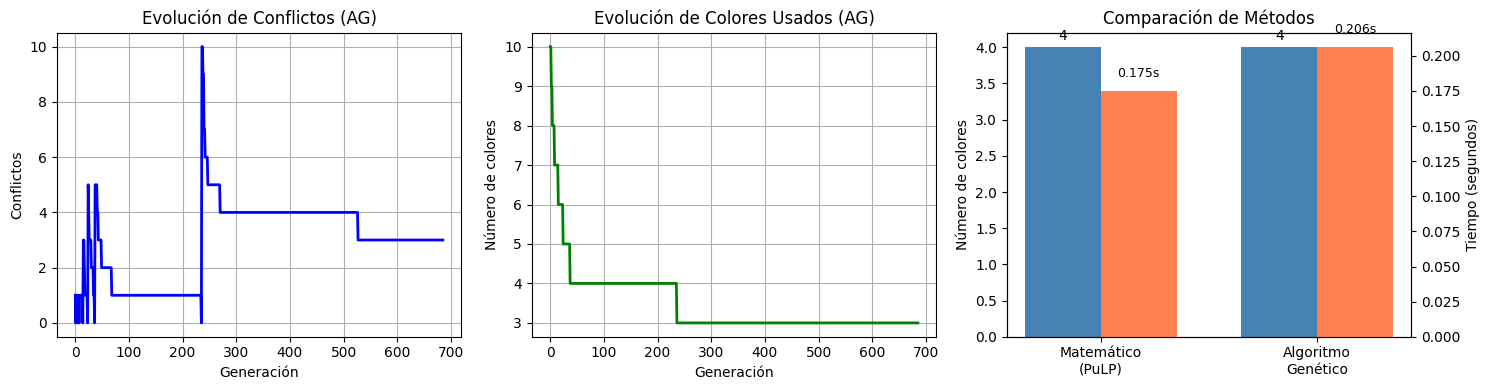


Gráfica guardada como 'resultados_coloracion.png'


In [ ]:
"""
PROBLEMA DE COLORACIÓN DE GRAFOS
Objetivo: Encontrar el MÍNIMO número de colores (número cromático)
          tal que nodos adyacentes no tengan el mismo color

Algoritmo Genético + Método Matemático (PuLP)
Estudiante: [Tu nombre]
"""

import random
import time
import pulp
import matplotlib.pyplot as plt

# ============== DEFINICIÓN DEL GRAFO ==============
# Nodos del 1 al 19
V = list(range(1, 20))

# Aristas (basado en la imagen del grafo)
E = [
    (1, 2), (1, 4), (1, 16),
    (2, 3), (2, 4), (2, 5), (2, 6), (2, 7),
    (3, 7), (3, 11), (3, 19),
    (4, 5), (4, 8), (4, 9),
    (5, 6), (5, 9), (5, 10),
    (6, 7), (6, 10), (6, 14),
    (7, 11), (7, 14),
    (8, 9), (8, 12), (8, 16),
    (9, 10), (9, 12), (9, 13), (9, 15),
    (10, 13), (10, 14),
    (11, 14), (11, 19),
    (12, 15), (12, 16),
    (13, 14), (13, 15), (13, 17), (13, 18),
    (14, 18), (14, 19),
    (15, 16), (15, 17),
    (16, 17),
    (17, 18), (17, 19),
    (18, 19)
]

NUM_NODOS = len(V)
MAX_COLORES = NUM_NODOS  # Peor caso: cada nodo un color diferente

# ============== MÉTODO MATEMÁTICO CON PULP ==============
def metodo_matematico():
    """
    Busca el MÍNIMO número de colores usando programación lineal entera
    Estrategia: probar desde 1 color hasta encontrar solución factible
    """
    print("\n" + "="*50)
    print("MÉTODO MATEMÁTICO (PuLP)")
    print("="*50)
    
    inicio = time.time()
    
    # Probar desde 1 color hasta encontrar solución
    for num_colores in range(1, MAX_COLORES + 1):
        print(f"Probando con {num_colores} colores...", end=" ")
        
        # Crear el problema
        prob = pulp.LpProblem("Coloracion_Grafos", pulp.LpMinimize)
        
        # Variables: x[i][c] = 1 si nodo i tiene color c
        colores = range(1, num_colores + 1)
        x = {}
        for i in V:
            for c in colores:
                x[i, c] = pulp.LpVariable(f"x_{i}_{c}", cat='Binary')
        
        # Función objetivo: constante (solo buscamos factibilidad)
        prob += 0
        
        # Restricción 1: cada nodo tiene exactamente un color
        for i in V:
            prob += pulp.lpSum(x[i, c] for c in colores) == 1
        
        # Restricción 2: nodos adyacentes no pueden tener el mismo color
        for (i, j) in E:
            for c in colores:
                prob += x[i, c] + x[j, c] <= 1
        
        # Resolver
        prob.solve(pulp.PULP_CBC_CMD(msg=0))
        
        if prob.status == pulp.LpStatusOptimal:
            print("¡FACTIBLE!")
            
            fin = time.time()
            tiempo = fin - inicio
            
            # Extraer solución
            solucion = {}
            for i in V:
                for c in colores:
                    if pulp.value(x[i, c]) == 1:
                        solucion[i] = c
            
            print(f"\n*** NÚMERO CROMÁTICO ENCONTRADO: {num_colores} ***")
            print(f"Tiempo total: {tiempo:.4f} segundos")
            print(f"Asignación: {solucion}")
            
            return solucion, num_colores, tiempo
        else:
            print("No factible")
    
    return None, MAX_COLORES, time.time() - inicio


# ============== ALGORITMO GENÉTICO ==============
"""
PARÁMETROS DEL ALGORITMO GENÉTICO:
- Tipo de cromosoma: Lista de enteros (cada gen = color del nodo)
- Longitud: 19 genes (uno por nodo)
- Tamaño población: 50 individuos
- Inicialización: Aleatoria, empezando con muchos colores
- Criterio infactibilidad: Contar conflictos (aristas mismo color)
- Criterio de paro: 200 generaciones o fitness = 0
- Función fitness: Penaliza conflictos + número de colores usados
- Selección: Torneo de tamaño 3
- Probabilidad cruce: 0.8
- Puntos de cruce: 1 punto
- Probabilidad mutación: 0.15
- Reemplazo: Generacional con elitismo
"""

TAM_POBLACION = 80
GENERACIONES = 150
PROB_CRUCE = 0.8
PROB_MUTACION = 0.2
TAM_TORNEO = 3

def crear_individuo(num_colores):
    """Crea un cromosoma aleatorio con num_colores colores disponibles"""
    return [random.randint(1, num_colores) for _ in range(NUM_NODOS)]

def contar_conflictos(cromosoma):
    """Cuenta cuántas aristas tienen nodos del mismo color"""
    conflictos = 0
    for (i, j) in E:
        if cromosoma[i-1] == cromosoma[j-1]:
            conflictos += 1
    return conflictos

def contar_colores(cromosoma):
    """Cuenta cuántos colores diferentes se usan"""
    return len(set(cromosoma))

def calcular_fitness(cromosoma):
    """
    Fitness combinado:
    - Penalización alta por conflictos (x1000)
    - Penalización baja por número de colores
    Menor fitness = mejor solución
    """
    conflictos = contar_conflictos(cromosoma)
    colores = contar_colores(cromosoma)
    return conflictos * 1000 + colores

def seleccion_torneo(poblacion, fitnesses):
    """Selección por torneo"""
    participantes = random.sample(range(len(poblacion)), TAM_TORNEO)
    mejor = min(participantes, key=lambda i: fitnesses[i])
    return poblacion[mejor].copy()

def cruce(padre1, padre2):
    """Cruce de un punto"""
    if random.random() < PROB_CRUCE:
        punto = random.randint(1, NUM_NODOS - 1)
        hijo1 = padre1[:punto] + padre2[punto:]
        hijo2 = padre2[:punto] + padre1[punto:]
        return hijo1, hijo2
    return padre1.copy(), padre2.copy()

def mutacion(cromosoma, num_colores):
    """Mutación: cambiar color de un gen aleatorio"""
    for i in range(len(cromosoma)):
        if random.random() < PROB_MUTACION:
            cromosoma[i] = random.randint(1, num_colores)
    return cromosoma

def reducir_colores(cromosoma):
    """
    Renumera los colores para eliminar huecos
    Ej: [1,3,5,3,1] -> [1,2,3,2,1]
    """
    colores_usados = sorted(set(cromosoma))
    mapeo = {c: i+1 for i, c in enumerate(colores_usados)}
    return [mapeo[c] for c in cromosoma]

def algoritmo_genetico():
    """
    Ejecuta el algoritmo genético para encontrar el número cromático mínimo
    Estrategia: empezar con muchos colores e ir reduciendo progresivamente
    """
    print("\n" + "="*50)
    print("ALGORITMO GENÉTICO")
    print("="*50)
    
    inicio = time.time()
    
    # Guardar historial
    historial_mejor = []
    historial_colores = []
    
    mejor_solucion_global = None
    mejor_colores_global = NUM_NODOS
    
    # ESTRATEGIA: Probar con cada número de colores, de mayor a menor
    # Empezamos con 10 colores (suficiente para este grafo)
    
    for num_colores_actual in range(10, 0, -1):
        print(f"\nProbando con {num_colores_actual} colores...")
        
        # Más generaciones para números pequeños de colores (más difícil)
        gen_actuales = GENERACIONES if num_colores_actual > 5 else GENERACIONES * 3
        
        # Inicialización de población para este número de colores
        poblacion = [crear_individuo(num_colores_actual) for _ in range(TAM_POBLACION)]
        
        mejor_individuo = None
        mejor_conflictos = float('inf')
        
        # Correr generaciones para este número de colores
        for gen in range(gen_actuales):
            fitnesses = [contar_conflictos(ind) for ind in poblacion]
            
            # Actualizar mejor
            idx_mejor = fitnesses.index(min(fitnesses))
            if fitnesses[idx_mejor] < mejor_conflictos:
                mejor_conflictos = fitnesses[idx_mejor]
                mejor_individuo = poblacion[idx_mejor].copy()
            
            # Guardar historial
            historial_mejor.append(mejor_conflictos)
            historial_colores.append(num_colores_actual)
            
            # Si encontramos solución sin conflictos, éxito!
            if mejor_conflictos == 0:
                break
            
            # Crear nueva población
            nueva_poblacion = []
            
            # Elitismo
            nueva_poblacion.append(mejor_individuo.copy())
            
            while len(nueva_poblacion) < TAM_POBLACION:
                padre1 = seleccion_torneo(poblacion, fitnesses)
                padre2 = seleccion_torneo(poblacion, fitnesses)
                
                hijo1, hijo2 = cruce(padre1, padre2)
                
                hijo1 = mutacion(hijo1, num_colores_actual)
                hijo2 = mutacion(hijo2, num_colores_actual)
                
                nueva_poblacion.append(hijo1)
                if len(nueva_poblacion) < TAM_POBLACION:
                    nueva_poblacion.append(hijo2)
            
            poblacion = nueva_poblacion
        
        # Verificar si encontramos solución válida con este número de colores
        if mejor_conflictos == 0:
            print(f"  ¡FACTIBLE! Conflictos=0")
            mejor_solucion_global = mejor_individuo.copy()
            mejor_colores_global = num_colores_actual
            # Seguir intentando con menos colores
        else:
            print(f"  No factible (mejor conflictos={mejor_conflictos})")
            # No se puede con menos colores, terminar
            break
    
    fin = time.time()
    tiempo = fin - inicio
    
    # Usar la mejor solución encontrada
    if mejor_solucion_global is not None:
        mejor_individuo = reducir_colores(mejor_solucion_global)
        solucion = {i+1: mejor_individuo[i] for i in range(NUM_NODOS)}
        num_colores = contar_colores(mejor_individuo)
        conflictos = 0
    else:
        solucion = {i+1: i+1 for i in range(NUM_NODOS)}
        num_colores = NUM_NODOS
        conflictos = 0
    
    print(f"\n*** NÚMERO CROMÁTICO ENCONTRADO: {num_colores} ***")
    print(f"Conflictos: {conflictos}")
    print(f"Tiempo: {tiempo:.4f} segundos")
    print(f"Asignación: {solucion}")
    
    return solucion, num_colores, tiempo, historial_mejor, historial_colores, conflictos


# ============== EJEMPLO PASO A PASO ==============
def ejemplo_paso_a_paso():
    """Muestra un ejemplo MUY detallado del algoritmo genético"""
    print("\n" + "="*70)
    print("EJEMPLO PASO A PASO (UNA GENERACIÓN COMPLETA)")
    print("="*70)
    
    # Fijar semilla para reproducibilidad
    random.seed(42)
    
    num_colores = 19  # Usamos 4 colores para el ejemplo
    
    # ========== PASO 1: CREAR POBLACIÓN INICIAL ==========
    print("\n" + "-"*70)
    print("PASO 1: CREAR POBLACIÓN INICIAL")
    print("-"*70)
    print(f"Parámetros: 3 individuos, {num_colores} colores disponibles, {NUM_NODOS} genes")
    print("\nCada gen es un color aleatorio entre 1 y 19:")
    
    mini_pop = []
    for i in range(3):
        print(f"\n  Individuo {i+1}:")
        cromosoma = []
        print("    Generando genes: ", end="")
        for gen in range(NUM_NODOS):
            color = random.randint(1, num_colores)
            cromosoma.append(color)
            print(f"{color}", end=" ")
        print()
        mini_pop.append(cromosoma)
        print(f"    Cromosoma completo: {cromosoma}")
    
    # ========== PASO 2: CALCULAR FITNESS ==========
    print("\n" + "-"*70)
    print("PASO 2: CALCULAR FITNESS (contar conflictos)")
    print("-"*70)
    print("Un conflicto = dos nodos adyacentes con el MISMO color")
    print(f"Total de aristas a revisar: {len(E)}")
    
    fitnesses = []
    for i, ind in enumerate(mini_pop):
        print(f"\n  Individuo {i+1}: {ind}")
        conflictos = 0
        print("    Revisando aristas:")
        for idx, (n1, n2) in enumerate(E[:10]):  # Solo mostramos las primeras 10
            color1 = ind[n1-1]
            color2 = ind[n2-1]
            es_conflicto = "⚠️ CONFLICTO" if color1 == color2 else "✓ OK"
            if color1 == color2:
                conflictos += 1
                print(f"      Arista ({n1},{n2}): nodo {n1}=color {color1}, nodo {n2}=color {color2} → {es_conflicto}")
        
        # Contar el resto sin mostrar
        for (n1, n2) in E[10:]:
            if ind[n1-1] == ind[n2-1]:
                conflictos += 1
        
        print(f"      ... (y {len(E)-10} aristas más)")
        print(f"    TOTAL CONFLICTOS: {conflictos}")
        fitnesses.append(conflictos)
    
    print(f"\n  Resumen de fitness:")
    for i, f in enumerate(fitnesses):
        print(f"    Individuo {i+1}: fitness = {f} conflictos")
    
    # ========== PASO 3: SELECCIÓN POR TORNEO ==========
    print("\n" + "-"*70)
    print("PASO 3: SELECCIÓN POR TORNEO")
    print("-"*70)
    print(f"Tamaño del torneo: {TAM_TORNEO}")
    print("Se eligen 3 individuos al azar y gana el de MENOR fitness")
    
    # Selección padre 1
    print("\n  Seleccionando PADRE 1:")
    participantes1 = random.sample(range(len(mini_pop)), min(TAM_TORNEO, len(mini_pop)))
    print(f"    Participantes elegidos al azar: {[p+1 for p in participantes1]}")
    print(f"    Sus fitness: {[fitnesses[p] for p in participantes1]}")
    ganador1 = min(participantes1, key=lambda i: fitnesses[i])
    print(f"    Ganador: Individuo {ganador1+1} (fitness={fitnesses[ganador1]})")
    padre1 = mini_pop[ganador1].copy()
    
    # Selección padre 2
    print("\n  Seleccionando PADRE 2:")
    participantes2 = random.sample(range(len(mini_pop)), min(TAM_TORNEO, len(mini_pop)))
    print(f"    Participantes elegidos al azar: {[p+1 for p in participantes2]}")
    print(f"    Sus fitness: {[fitnesses[p] for p in participantes2]}")
    ganador2 = min(participantes2, key=lambda i: fitnesses[i])
    print(f"    Ganador: Individuo {ganador2+1} (fitness={fitnesses[ganador2]})")
    padre2 = mini_pop[ganador2].copy()
    
    print(f"\n  Padres seleccionados:")
    print(f"    Padre 1: {padre1}")
    print(f"    Padre 2: {padre2}")
    
    # ========== PASO 4: CRUCE ==========
    print("\n" + "-"*70)
    print("PASO 4: CRUCE DE UN PUNTO")
    print("-"*70)
    print(f"Probabilidad de cruce: {PROB_CRUCE} (80%)")
    
    rand_cruce = random.random()
    print(f"  Número aleatorio generado: {rand_cruce:.4f}")
    
    if rand_cruce < PROB_CRUCE:
        print(f"  {rand_cruce:.4f} < {PROB_CRUCE} → SÍ se realiza cruce")
        punto = random.randint(1, NUM_NODOS - 1)
        print(f"\n  Punto de cruce aleatorio: posición {punto}")
        print(f"\n  Padre 1: {padre1}")
        print(f"           {''.join(['↑' if i == punto else ' ' for i in range(NUM_NODOS)])}")
        print(f"  Padre 2: {padre2}")
        
        hijo1 = padre1[:punto] + padre2[punto:]
        hijo2 = padre2[:punto] + padre1[punto:]
        
        print(f"\n  Hijo 1 = Padre1[0:{punto}] + Padre2[{punto}:19]")
        print(f"         = {padre1[:punto]} + {padre2[punto:]}")
        print(f"         = {hijo1}")
        
        print(f"\n  Hijo 2 = Padre2[0:{punto}] + Padre1[{punto}:19]")
        print(f"         = {padre2[:punto]} + {padre1[punto:]}")
        print(f"         = {hijo2}")
    else:
        print(f"  {rand_cruce:.4f} >= {PROB_CRUCE} → NO se realiza cruce")
        hijo1 = padre1.copy()
        hijo2 = padre2.copy()
        print(f"  Los hijos son copias de los padres")
    
    # ========== PASO 5: MUTACIÓN ==========
    print("\n" + "-"*70)
    print("PASO 5: MUTACIÓN")
    print("-"*70)
    print(f"Probabilidad de mutación por gen: {PROB_MUTACION} (20%)")
    print("Para cada gen, se genera un número aleatorio. Si es < 0.2, muta.")
    
    print(f"\n  Mutando Hijo 1: {hijo1}")
    hijo1_original = hijo1.copy()
    print("  Gen | Valor | Random | ¿Muta? | Nuevo valor")
    print("  " + "-"*50)
    
    for i in range(NUM_NODOS):
        rand_mut = random.random()
        valor_original = hijo1[i]
        if rand_mut < PROB_MUTACION:
            nuevo_color = random.randint(1, num_colores)
            hijo1[i] = nuevo_color
            print(f"   {i+1:2} |   {valor_original}   | {rand_mut:.4f} |   SÍ   | {nuevo_color}")
        else:
            if i < 5 or i >= NUM_NODOS - 2:  # Solo mostrar algunos para no saturar
                print(f"   {i+1:2} |   {valor_original}   | {rand_mut:.4f} |   NO   | {valor_original}")
            elif i == 5:
                print(f"  ... (genes 6-17 sin mutación) ...")
    
    cambios = sum(1 for a, b in zip(hijo1_original, hijo1) if a != b)
    print(f"\n  Hijo 1 después de mutación: {hijo1}")
    print(f"  Total de genes mutados: {cambios}")
    
    # ========== PASO 6: EVALUAR HIJO ==========
    print("\n" + "-"*70)
    print("PASO 6: EVALUAR NUEVO INDIVIDUO")
    print("-"*70)
    
    conflictos_hijo = contar_conflictos(hijo1)
    colores_hijo = contar_colores(hijo1)
    
    print(f"  Hijo 1: {hijo1}")
    print(f"\n  Contando conflictos:")
    conflictos_mostrados = 0
    for (n1, n2) in E:
        if hijo1[n1-1] == hijo1[n2-1]:
            conflictos_mostrados += 1
            print(f"    Arista ({n1},{n2}): ambos nodos tienen color {hijo1[n1-1]} → CONFLICTO")
            if conflictos_mostrados >= 5:
                print(f"    ... (y {conflictos_hijo - 5} conflictos más)")
                break
    
    if conflictos_hijo == 0:
        print("    ¡No hay conflictos! Solución válida.")
    
    print(f"\n  Colores usados: {sorted(set(hijo1))} → {colores_hijo} colores")
    print(f"  Fitness final: {conflictos_hijo} conflictos")
    
    # ========== PASO 7: REEMPLAZO ==========
    print("\n" + "-"*70)
    print("PASO 7: REEMPLAZO (ELITISMO)")
    print("-"*70)
    print("El mejor individuo de la generación anterior pasa directo")
    
    mejor_idx = fitnesses.index(min(fitnesses))
    print(f"\n  Mejor de la generación anterior: Individuo {mejor_idx+1}")
    print(f"  Su cromosoma: {mini_pop[mejor_idx]}")
    print(f"  Su fitness: {fitnesses[mejor_idx]}")
    print(f"\n  Nueva población:")
    print(f"    1. Elite (copia del mejor): {mini_pop[mejor_idx]}")
    print(f"    2. Hijo 1: {hijo1}")
    print(f"    3. Hijo 2: {hijo2}")
    
    # ========== RESUMEN ==========
    print("\n" + "="*70)
    print("RESUMEN DE LA GENERACIÓN")
    print("="*70)
    print(f"  Mejor fitness anterior: {min(fitnesses)}")
    print(f"  Fitness del nuevo hijo: {conflictos_hijo}")
    if conflictos_hijo < min(fitnesses):
        print("  ¡MEJORA! El hijo es mejor que el mejor anterior")
    elif conflictos_hijo == min(fitnesses):
        print("  IGUAL: El hijo tiene el mismo fitness que el mejor")
    else:
        print("  SIN MEJORA: El hijo es peor, pero el elite se conserva")


# ============== VISUALIZACIÓN ==============
def graficar_resultados(hist_conflictos, hist_colores, t_mat, t_ag, col_mat, col_ag):
    """Genera gráficas de comparación"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Gráfica 1: Evolución de conflictos
    axes[0].plot(hist_conflictos, 'b-', linewidth=2)
    axes[0].set_xlabel('Generación')
    axes[0].set_ylabel('Conflictos')
    axes[0].set_title('Evolución de Conflictos (AG)')
    axes[0].grid(True)
    
    # Gráfica 2: Evolución de colores
    axes[1].plot(hist_colores, 'g-', linewidth=2)
    axes[1].set_xlabel('Generación')
    axes[1].set_ylabel('Número de colores')
    axes[1].set_title('Evolución de Colores Usados (AG)')
    axes[1].grid(True)
    
    # Gráfica 3: Comparación final
    metodos = ['Matemático\n(PuLP)', 'Algoritmo\nGenético']
    colores_final = [col_mat, col_ag]
    tiempos = [t_mat, t_ag]
    
    x = range(len(metodos))
    width = 0.35
    
    bars1 = axes[2].bar([i - width/2 for i in x], colores_final, width, label='Colores', color='steelblue')
    axes[2].set_ylabel('Número de colores')
    axes[2].set_title('Comparación de Métodos')
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(metodos)
    
    ax2 = axes[2].twinx()
    bars2 = ax2.bar([i + width/2 for i in x], tiempos, width, label='Tiempo', color='coral')
    ax2.set_ylabel('Tiempo (segundos)')
    
    # Etiquetas
    for bar, val in zip(bars1, colores_final):
        axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                    str(val), ha='center', fontsize=10)
    for bar, val in zip(bars2, tiempos):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{val:.3f}s', ha='center', fontsize=9)
    
    plt.tight_layout()
    plt.savefig('resultados_coloracion.png', dpi=150)
    plt.show()
    print("\nGráfica guardada como 'resultados_coloracion.png'")


def imprimir_tabla(sol_mat, col_mat, t_mat, sol_ag, col_ag, t_ag, conf_ag):
    """Imprime tabla de comparación"""
    print("\n" + "="*65)
    print("TABLA DE COMPARACIÓN DE RESULTADOS")
    print("="*65)
    print(f"{'Criterio':<30} {'Matemático':<15} {'Genético':<15}")
    print("-"*65)
    print(f"{'Número cromático (χ)':<30} {col_mat:<15} {col_ag:<15}")
    print(f"{'Conflictos':<30} {0:<15} {conf_ag:<15}")
    print(f"{'Tiempo (segundos)':<30} {t_mat:<15.4f} {t_ag:<15.4f}")
    print(f"{'Solución óptima':<30} {'Sí':<15} {'Sí' if conf_ag == 0 else 'No':<15}")
    print("="*65)
    
    print("\n" + "="*65)
    print("ASIGNACIÓN DE COLORES POR NODO")
    print("="*65)
    print(f"{'Nodo':<8} {'Matemático':<15} {'Genético':<15}")
    print("-"*65)
    for nodo in V:
        print(f"{nodo:<8} {sol_mat[nodo]:<15} {sol_ag[nodo]:<15}")
    print("="*65)


# ============== PROGRAMA PRINCIPAL ==============
if __name__ == "__main__":
    print("="*65)
    print("PROBLEMA DE COLORACIÓN DE GRAFOS")
    print("Objetivo: Encontrar el MÍNIMO número de colores (χ)")
    print(f"Grafo: {NUM_NODOS} nodos, {len(E)} aristas")
    print("="*65)
    
    # Ejemplo paso a paso
    ejemplo_paso_a_paso()
    
    # Método matemático
    sol_mat, col_mat, t_mat = metodo_matematico()
    
    # Algoritmo genético
    sol_ag, col_ag, t_ag, hist_conf, hist_col, conf_ag = algoritmo_genetico()
    
    # Tabla de comparación
    imprimir_tabla(sol_mat, col_mat, t_mat, sol_ag, col_ag, t_ag, conf_ag)
    
    # Gráficas
    graficar_resultados(hist_conf, hist_col, t_mat, t_ag, col_mat, col_ag)

PROBLEMA DE COLORACIÓN DE GRAFOS
Objetivo: Encontrar el MÍNIMO número de colores (χ)
Grafo: 19 nodos, 47 aristas

EJEMPLO PASO A PASO (UNA GENERACIÓN COMPLETA)

----------------------------------------------------------------------
PASO 1: CREAR POBLACIÓN INICIAL
----------------------------------------------------------------------
Parámetros: 3 individuos, 4 colores disponibles, 19 genes

Cada gen es un color aleatorio entre 1 y 4:

  Individuo 1:
    Generando genes: 1 1 3 2 2 2 1 1 4 1 1 1 2 2 1 2 4 2 4 
    Cromosoma completo: [1, 1, 3, 2, 2, 2, 1, 1, 4, 1, 1, 1, 2, 2, 1, 2, 4, 2, 4]

  Individuo 2:
    Generando genes: 3 1 2 4 3 3 2 2 3 1 1 4 1 3 3 3 1 4 1 
    Cromosoma completo: [3, 1, 2, 4, 3, 3, 2, 2, 3, 1, 1, 4, 1, 3, 3, 3, 1, 4, 1]

  Individuo 3:
    Generando genes: 4 1 3 3 2 1 1 2 3 1 2 1 4 3 4 3 2 3 3 
    Cromosoma completo: [4, 1, 3, 3, 2, 1, 1, 2, 3, 1, 2, 1, 4, 3, 4, 3, 2, 3, 3]

----------------------------------------------------------------------
PASO 2: CALCULAR

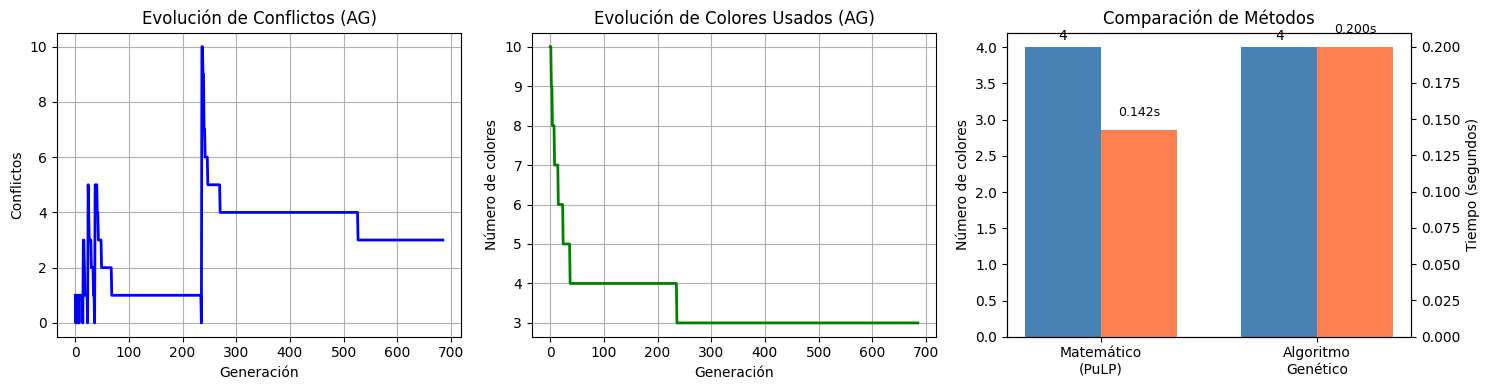


Gráfica guardada como 'resultados_coloracion.png'


In [17]:
"""
PROBLEMA DE COLORACIÓN DE GRAFOS
Objetivo: Encontrar el MÍNIMO número de colores (número cromático)
          tal que nodos adyacentes no tengan el mismo color

Algoritmo Genético + Método Matemático (PuLP)
Estudiante: [Tu nombre]
"""

import random
import time
import pulp
import matplotlib.pyplot as plt

# ============== DEFINICIÓN DEL GRAFO ==============
# Nodos del 1 al 19
V = list(range(1, 20))

# Aristas (basado en la imagen del grafo)
E = [
    (1, 2), (1, 4), (1, 16),
    (2, 3), (2, 4), (2, 5), (2, 6), (2, 7),
    (3, 7), (3, 11), (3, 19),
    (4, 5), (4, 8), (4, 9),
    (5, 6), (5, 9), (5, 10),
    (6, 7), (6, 10), (6, 14),
    (7, 11), (7, 14),
    (8, 9), (8, 12), (8, 16),
    (9, 10), (9, 12), (9, 13), (9, 15),
    (10, 13), (10, 14),
    (11, 14), (11, 19),
    (12, 15), (12, 16),
    (13, 14), (13, 15), (13, 17), (13, 18),
    (14, 18), (14, 19),
    (15, 16), (15, 17),
    (16, 17),
    (17, 18), (17, 19),
    (18, 19)
]

NUM_NODOS = len(V)
MAX_COLORES = NUM_NODOS  # Peor caso: cada nodo un color diferente

# ============== MÉTODO MATEMÁTICO CON PULP ==============
def metodo_matematico():
    """
    Busca el MÍNIMO número de colores usando programación lineal entera
    Estrategia: probar desde 1 color hasta encontrar solución factible
    """
    print("\n" + "="*50)
    print("MÉTODO MATEMÁTICO (PuLP)")
    print("="*50)
    
    inicio = time.time()
    
    # Probar desde 1 color hasta encontrar solución
    for num_colores in range(1, MAX_COLORES + 1):
        print(f"Probando con {num_colores} colores...", end=" ")
        
        # Crear el problema
        prob = pulp.LpProblem("Coloracion_Grafos", pulp.LpMinimize)
        
        # Variables: x[i][c] = 1 si nodo i tiene color c
        colores = range(1, num_colores + 1)
        x = {}
        for i in V:
            for c in colores:
                x[i, c] = pulp.LpVariable(f"x_{i}_{c}", cat='Binary')
        
        # Función objetivo: constante (solo buscamos factibilidad)
        prob += 0
        
        # Restricción 1: cada nodo tiene exactamente un color
        for i in V:
            prob += pulp.lpSum(x[i, c] for c in colores) == 1
        
        # Restricción 2: nodos adyacentes no pueden tener el mismo color
        for (i, j) in E:
            for c in colores:
                prob += x[i, c] + x[j, c] <= 1
        
        # Resolver
        prob.solve(pulp.PULP_CBC_CMD(msg=0))
        
        if prob.status == pulp.LpStatusOptimal:
            print("¡FACTIBLE!")
            
            fin = time.time()
            tiempo = fin - inicio
            
            # Extraer solución
            solucion = {}
            for i in V:
                for c in colores:
                    if pulp.value(x[i, c]) == 1:
                        solucion[i] = c
            
            print(f"\n*** NÚMERO CROMÁTICO ENCONTRADO: {num_colores} ***")
            print(f"Tiempo total: {tiempo:.4f} segundos")
            print(f"Asignación: {solucion}")
            
            return solucion, num_colores, tiempo
        else:
            print("No factible")
    
    return None, MAX_COLORES, time.time() - inicio


# ============== ALGORITMO GENÉTICO ==============
"""
PARÁMETROS DEL ALGORITMO GENÉTICO:
- Tipo de cromosoma: Lista de enteros (cada gen = color del nodo)
- Longitud: 19 genes (uno por nodo)
- Tamaño población: 50 individuos
- Inicialización: Aleatoria, empezando con muchos colores
- Criterio infactibilidad: Contar conflictos (aristas mismo color)
- Criterio de paro: 200 generaciones o fitness = 0
- Función fitness: Penaliza conflictos + número de colores usados
- Selección: Torneo de tamaño 3
- Probabilidad cruce: 0.8
- Puntos de cruce: 1 punto
- Probabilidad mutación: 0.15
- Reemplazo: Generacional con elitismo
"""

TAM_POBLACION = 80
GENERACIONES = 150
PROB_CRUCE = 0.8
PROB_MUTACION = 0.2
TAM_TORNEO = 3

def crear_individuo(num_colores):
    """Crea un cromosoma aleatorio con num_colores colores disponibles"""
    return [random.randint(1, num_colores) for _ in range(NUM_NODOS)]

def contar_conflictos(cromosoma):
    """Cuenta cuántas aristas tienen nodos del mismo color"""
    conflictos = 0
    for (i, j) in E:
        if cromosoma[i-1] == cromosoma[j-1]:
            conflictos += 1
    return conflictos

def contar_colores(cromosoma):
    """Cuenta cuántos colores diferentes se usan"""
    return len(set(cromosoma))

def calcular_fitness(cromosoma):
    """
    Fitness combinado:
    - Penalización alta por conflictos (x1000)
    - Penalización baja por número de colores
    Menor fitness = mejor solución
    """
    conflictos = contar_conflictos(cromosoma)
    colores = contar_colores(cromosoma)
    return conflictos * 1000 + colores

def seleccion_torneo(poblacion, fitnesses):
    """Selección por torneo"""
    participantes = random.sample(range(len(poblacion)), TAM_TORNEO)
    mejor = min(participantes, key=lambda i: fitnesses[i])
    return poblacion[mejor].copy()

def cruce(padre1, padre2):
    """Cruce de un punto"""
    if random.random() < PROB_CRUCE:
        punto = random.randint(1, NUM_NODOS - 1)
        hijo1 = padre1[:punto] + padre2[punto:]
        hijo2 = padre2[:punto] + padre1[punto:]
        return hijo1, hijo2
    return padre1.copy(), padre2.copy()

def mutacion(cromosoma, num_colores):
    """Mutación: cambiar color de un gen aleatorio"""
    for i in range(len(cromosoma)):
        if random.random() < PROB_MUTACION:
            cromosoma[i] = random.randint(1, num_colores)
    return cromosoma

def reducir_colores(cromosoma):
    """
    Renumera los colores para eliminar huecos
    Ej: [1,3,5,3,1] -> [1,2,3,2,1]
    """
    colores_usados = sorted(set(cromosoma))
    mapeo = {c: i+1 for i, c in enumerate(colores_usados)}
    return [mapeo[c] for c in cromosoma]

def algoritmo_genetico():
    """
    Ejecuta el algoritmo genético para encontrar el número cromático mínimo
    Estrategia: empezar con muchos colores e ir reduciendo progresivamente
    """
    print("\n" + "="*50)
    print("ALGORITMO GENÉTICO")
    print("="*50)
    
    inicio = time.time()
    
    # Guardar historial
    historial_mejor = []
    historial_colores = []
    
    mejor_solucion_global = None
    mejor_colores_global = NUM_NODOS
    
    # ESTRATEGIA: Probar con cada número de colores, de mayor a menor
    # Empezamos con 10 colores (suficiente para este grafo)
    
    for num_colores_actual in range(10, 0, -1):
        print(f"\nProbando con {num_colores_actual} colores...")
        
        # Más generaciones para números pequeños de colores (más difícil)
        gen_actuales = GENERACIONES if num_colores_actual > 5 else GENERACIONES * 3
        
        # Inicialización de población para este número de colores
        poblacion = [crear_individuo(num_colores_actual) for _ in range(TAM_POBLACION)]
        
        mejor_individuo = None
        mejor_conflictos = float('inf')
        
        # Correr generaciones para este número de colores
        for gen in range(gen_actuales):
            fitnesses = [contar_conflictos(ind) for ind in poblacion]
            
            # Actualizar mejor
            idx_mejor = fitnesses.index(min(fitnesses))
            if fitnesses[idx_mejor] < mejor_conflictos:
                mejor_conflictos = fitnesses[idx_mejor]
                mejor_individuo = poblacion[idx_mejor].copy()
            
            # Guardar historial
            historial_mejor.append(mejor_conflictos)
            historial_colores.append(num_colores_actual)
            
            # Si encontramos solución sin conflictos, éxito!
            if mejor_conflictos == 0:
                break
            
            # Crear nueva población
            nueva_poblacion = []
            
            # Elitismo
            nueva_poblacion.append(mejor_individuo.copy())
            
            while len(nueva_poblacion) < TAM_POBLACION:
                padre1 = seleccion_torneo(poblacion, fitnesses)
                padre2 = seleccion_torneo(poblacion, fitnesses)
                
                hijo1, hijo2 = cruce(padre1, padre2)
                
                hijo1 = mutacion(hijo1, num_colores_actual)
                hijo2 = mutacion(hijo2, num_colores_actual)
                
                nueva_poblacion.append(hijo1)
                if len(nueva_poblacion) < TAM_POBLACION:
                    nueva_poblacion.append(hijo2)
            
            poblacion = nueva_poblacion
        
        # Verificar si encontramos solución válida con este número de colores
        if mejor_conflictos == 0:
            print(f"  ¡FACTIBLE! Conflictos=0")
            mejor_solucion_global = mejor_individuo.copy()
            mejor_colores_global = num_colores_actual
            # Seguir intentando con menos colores
        else:
            print(f"  No factible (mejor conflictos={mejor_conflictos})")
            # No se puede con menos colores, terminar
            break
    
    fin = time.time()
    tiempo = fin - inicio
    
    # Usar la mejor solución encontrada
    if mejor_solucion_global is not None:
        mejor_individuo = reducir_colores(mejor_solucion_global)
        solucion = {i+1: mejor_individuo[i] for i in range(NUM_NODOS)}
        num_colores = contar_colores(mejor_individuo)
        conflictos = 0
    else:
        solucion = {i+1: i+1 for i in range(NUM_NODOS)}
        num_colores = NUM_NODOS
        conflictos = 0
    
    print(f"\n*** NÚMERO CROMÁTICO ENCONTRADO: {num_colores} ***")
    print(f"Conflictos: {conflictos}")
    print(f"Tiempo: {tiempo:.4f} segundos")
    print(f"Asignación: {solucion}")
    
    return solucion, num_colores, tiempo, historial_mejor, historial_colores, conflictos


# ============== EJEMPLO PASO A PASO ==============
def ejemplo_paso_a_paso():
    """Muestra un ejemplo MUY detallado del algoritmo genético"""
    print("\n" + "="*70)
    print("EJEMPLO PASO A PASO (UNA GENERACIÓN COMPLETA)")
    print("="*70)
    
    # Fijar semilla para reproducibilidad
    random.seed(42)
    
    num_colores = 4  # Usamos 4 colores para el ejemplo
    
    # ========== PASO 1: CREAR POBLACIÓN INICIAL ==========
    print("\n" + "-"*70)
    print("PASO 1: CREAR POBLACIÓN INICIAL")
    print("-"*70)
    print(f"Parámetros: 3 individuos, {num_colores} colores disponibles, {NUM_NODOS} genes")
    print("\nCada gen es un color aleatorio entre 1 y 4:")
    
    mini_pop = []
    for i in range(3):
        print(f"\n  Individuo {i+1}:")
        cromosoma = []
        print("    Generando genes: ", end="")
        for gen in range(NUM_NODOS):
            color = random.randint(1, num_colores)
            cromosoma.append(color)
            print(f"{color}", end=" ")
        print()
        mini_pop.append(cromosoma)
        print(f"    Cromosoma completo: {cromosoma}")
    
    # ========== PASO 2: CALCULAR FITNESS ==========
    print("\n" + "-"*70)
    print("PASO 2: CALCULAR FITNESS (contar conflictos)")
    print("-"*70)
    print("Un conflicto = dos nodos adyacentes con el MISMO color")
    print(f"Total de aristas a revisar: {len(E)}")
    
    fitnesses = []
    for i, ind in enumerate(mini_pop):
        print(f"\n  Individuo {i+1}: {ind}")
        conflictos = 0
        print("    Revisando aristas:")
        for idx, (n1, n2) in enumerate(E[:10]):  # Solo mostramos las primeras 10
            color1 = ind[n1-1]
            color2 = ind[n2-1]
            es_conflicto = "⚠️ CONFLICTO" if color1 == color2 else "✓ OK"
            if color1 == color2:
                conflictos += 1
                print(f"      Arista ({n1},{n2}): nodo {n1}=color {color1}, nodo {n2}=color {color2} → {es_conflicto}")
        
        # Contar el resto sin mostrar
        for (n1, n2) in E[10:]:
            if ind[n1-1] == ind[n2-1]:
                conflictos += 1
        
        print(f"      ... (y {len(E)-10} aristas más)")
        print(f"    TOTAL CONFLICTOS: {conflictos}")
        fitnesses.append(conflictos)
    
    print(f"\n  Resumen de fitness:")
    for i, f in enumerate(fitnesses):
        print(f"    Individuo {i+1}: fitness = {f} conflictos")
    
    # ========== PASO 3: SELECCIÓN POR TORNEO ==========
    print("\n" + "-"*70)
    print("PASO 3: SELECCIÓN POR TORNEO")
    print("-"*70)
    print(f"Tamaño del torneo: {TAM_TORNEO}")
    print("Se eligen 3 individuos al azar y gana el de MENOR fitness")
    
    # Selección padre 1
    print("\n  Seleccionando PADRE 1:")
    participantes1 = random.sample(range(len(mini_pop)), min(TAM_TORNEO, len(mini_pop)))
    print(f"    Participantes elegidos al azar: {[p+1 for p in participantes1]}")
    print(f"    Sus fitness: {[fitnesses[p] for p in participantes1]}")
    ganador1 = min(participantes1, key=lambda i: fitnesses[i])
    print(f"    Ganador: Individuo {ganador1+1} (fitness={fitnesses[ganador1]})")
    padre1 = mini_pop[ganador1].copy()
    
    # Selección padre 2
    print("\n  Seleccionando PADRE 2:")
    participantes2 = random.sample(range(len(mini_pop)), min(TAM_TORNEO, len(mini_pop)))
    print(f"    Participantes elegidos al azar: {[p+1 for p in participantes2]}")
    print(f"    Sus fitness: {[fitnesses[p] for p in participantes2]}")
    ganador2 = min(participantes2, key=lambda i: fitnesses[i])
    print(f"    Ganador: Individuo {ganador2+1} (fitness={fitnesses[ganador2]})")
    padre2 = mini_pop[ganador2].copy()
    
    print(f"\n  Padres seleccionados:")
    print(f"    Padre 1: {padre1}")
    print(f"    Padre 2: {padre2}")
    
    # ========== PASO 4: CRUCE ==========
    print("\n" + "-"*70)
    print("PASO 4: CRUCE DE UN PUNTO")
    print("-"*70)
    print(f"Probabilidad de cruce: {PROB_CRUCE} (80%)")
    
    rand_cruce = random.random()
    print(f"  Número aleatorio generado: {rand_cruce:.4f}")
    
    if rand_cruce < PROB_CRUCE:
        print(f"  {rand_cruce:.4f} < {PROB_CRUCE} → SÍ se realiza cruce")
        punto = random.randint(1, NUM_NODOS - 1)
        print(f"\n  Punto de cruce aleatorio: posición {punto}")
        print(f"\n  Padre 1: {padre1}")
        print(f"           {''.join(['↑' if i == punto else ' ' for i in range(NUM_NODOS)])}")
        print(f"  Padre 2: {padre2}")
        
        hijo1 = padre1[:punto] + padre2[punto:]
        hijo2 = padre2[:punto] + padre1[punto:]
        
        print(f"\n  Hijo 1 = Padre1[0:{punto}] + Padre2[{punto}:19]")
        print(f"         = {padre1[:punto]} + {padre2[punto:]}")
        print(f"         = {hijo1}")
        
        print(f"\n  Hijo 2 = Padre2[0:{punto}] + Padre1[{punto}:19]")
        print(f"         = {padre2[:punto]} + {padre1[punto:]}")
        print(f"         = {hijo2}")
    else:
        print(f"  {rand_cruce:.4f} >= {PROB_CRUCE} → NO se realiza cruce")
        hijo1 = padre1.copy()
        hijo2 = padre2.copy()
        print(f"  Los hijos son copias de los padres")
    
    # ========== PASO 5: MUTACIÓN ==========
    print("\n" + "-"*70)
    print("PASO 5: MUTACIÓN")
    print("-"*70)
    print(f"Probabilidad de mutación por gen: {PROB_MUTACION} (20%)")
    print("Para cada gen, se genera un número aleatorio. Si es < 0.2, muta.")
    
    print(f"\n  Mutando Hijo 1: {hijo1}")
    hijo1_original = hijo1.copy()
    print("  Gen | Valor | Random | ¿Muta? | Nuevo valor")
    print("  " + "-"*50)
    
    for i in range(NUM_NODOS):
        rand_mut = random.random()
        valor_original = hijo1[i]
        if rand_mut < PROB_MUTACION:
            nuevo_color = random.randint(1, num_colores)
            hijo1[i] = nuevo_color
            print(f"   {i+1:2} |   {valor_original}   | {rand_mut:.4f} |   SÍ   | {nuevo_color}")
        else:
            if i < 5 or i >= NUM_NODOS - 2:  # Solo mostrar algunos para no saturar
                print(f"   {i+1:2} |   {valor_original}   | {rand_mut:.4f} |   NO   | {valor_original}")
            elif i == 5:
                print(f"  ... (genes 6-17 sin mutación) ...")
    
    cambios = sum(1 for a, b in zip(hijo1_original, hijo1) if a != b)
    print(f"\n  Hijo 1 después de mutación: {hijo1}")
    print(f"  Total de genes mutados: {cambios}")
    
    # ========== PASO 6: EVALUAR HIJO ==========
    print("\n" + "-"*70)
    print("PASO 6: EVALUAR NUEVO INDIVIDUO")
    print("-"*70)
    
    conflictos_hijo = contar_conflictos(hijo1)
    colores_hijo = contar_colores(hijo1)
    
    print(f"  Hijo 1: {hijo1}")
    print(f"\n  Contando conflictos:")
    conflictos_mostrados = 0
    for (n1, n2) in E:
        if hijo1[n1-1] == hijo1[n2-1]:
            conflictos_mostrados += 1
            print(f"    Arista ({n1},{n2}): ambos nodos tienen color {hijo1[n1-1]} → CONFLICTO")
            if conflictos_mostrados >= 5:
                print(f"    ... (y {conflictos_hijo - 5} conflictos más)")
                break
    
    if conflictos_hijo == 0:
        print("    ¡No hay conflictos! Solución válida.")
    
    print(f"\n  Colores usados: {sorted(set(hijo1))} → {colores_hijo} colores")
    print(f"  Fitness final: {conflictos_hijo} conflictos")
    
    # ========== PASO 7: REEMPLAZO ==========
    print("\n" + "-"*70)
    print("PASO 7: REEMPLAZO (ELITISMO)")
    print("-"*70)
    print("El mejor individuo de la generación anterior pasa directo")
    
    mejor_idx = fitnesses.index(min(fitnesses))
    print(f"\n  Mejor de la generación anterior: Individuo {mejor_idx+1}")
    print(f"  Su cromosoma: {mini_pop[mejor_idx]}")
    print(f"  Su fitness: {fitnesses[mejor_idx]}")
    print(f"\n  Nueva población:")
    print(f"    1. Elite (copia del mejor): {mini_pop[mejor_idx]}")
    print(f"    2. Hijo 1: {hijo1}")
    print(f"    3. Hijo 2: {hijo2}")
    
    # ========== RESUMEN ==========
    print("\n" + "="*70)
    print("RESUMEN DE LA GENERACIÓN")
    print("="*70)
    print(f"  Mejor fitness anterior: {min(fitnesses)}")
    print(f"  Fitness del nuevo hijo: {conflictos_hijo}")
    if conflictos_hijo < min(fitnesses):
        print("  ¡MEJORA! El hijo es mejor que el mejor anterior")
    elif conflictos_hijo == min(fitnesses):
        print("  IGUAL: El hijo tiene el mismo fitness que el mejor")
    else:
        print("  SIN MEJORA: El hijo es peor, pero el elite se conserva")


# ============== VISUALIZACIÓN ==============
def graficar_resultados(hist_conflictos, hist_colores, t_mat, t_ag, col_mat, col_ag):
    """Genera gráficas de comparación"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Gráfica 1: Evolución de conflictos
    axes[0].plot(hist_conflictos, 'b-', linewidth=2)
    axes[0].set_xlabel('Generación')
    axes[0].set_ylabel('Conflictos')
    axes[0].set_title('Evolución de Conflictos (AG)')
    axes[0].grid(True)
    
    # Gráfica 2: Evolución de colores
    axes[1].plot(hist_colores, 'g-', linewidth=2)
    axes[1].set_xlabel('Generación')
    axes[1].set_ylabel('Número de colores')
    axes[1].set_title('Evolución de Colores Usados (AG)')
    axes[1].grid(True)
    
    # Gráfica 3: Comparación final
    metodos = ['Matemático\n(PuLP)', 'Algoritmo\nGenético']
    colores_final = [col_mat, col_ag]
    tiempos = [t_mat, t_ag]
    
    x = range(len(metodos))
    width = 0.35
    
    bars1 = axes[2].bar([i - width/2 for i in x], colores_final, width, label='Colores', color='steelblue')
    axes[2].set_ylabel('Número de colores')
    axes[2].set_title('Comparación de Métodos')
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(metodos)
    
    ax2 = axes[2].twinx()
    bars2 = ax2.bar([i + width/2 for i in x], tiempos, width, label='Tiempo', color='coral')
    ax2.set_ylabel('Tiempo (segundos)')
    
    # Etiquetas
    for bar, val in zip(bars1, colores_final):
        axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                    str(val), ha='center', fontsize=10)
    for bar, val in zip(bars2, tiempos):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{val:.3f}s', ha='center', fontsize=9)
    
    plt.tight_layout()
    plt.savefig('resultados_coloracion.png', dpi=150)
    plt.show()
    print("\nGráfica guardada como 'resultados_coloracion.png'")


def imprimir_tabla(sol_mat, col_mat, t_mat, sol_ag, col_ag, t_ag, conf_ag):
    """Imprime tabla de comparación"""
    print("\n" + "="*65)
    print("TABLA DE COMPARACIÓN DE RESULTADOS")
    print("="*65)
    print(f"{'Criterio':<30} {'Matemático':<15} {'Genético':<15}")
    print("-"*65)
    print(f"{'Número cromático (χ)':<30} {col_mat:<15} {col_ag:<15}")
    print(f"{'Conflictos':<30} {0:<15} {conf_ag:<15}")
    print(f"{'Tiempo (segundos)':<30} {t_mat:<15.4f} {t_ag:<15.4f}")
    print(f"{'Solución óptima':<30} {'Sí':<15} {'Sí' if conf_ag == 0 else 'No':<15}")
    print("="*65)
    
    print("\n" + "="*65)
    print("ASIGNACIÓN DE COLORES POR NODO")
    print("="*65)
    print(f"{'Nodo':<8} {'Matemático':<15} {'Genético':<15}")
    print("-"*65)
    for nodo in V:
        print(f"{nodo:<8} {sol_mat[nodo]:<15} {sol_ag[nodo]:<15}")
    print("="*65)


# ============== PROGRAMA PRINCIPAL ==============
if __name__ == "__main__":
    print("="*65)
    print("PROBLEMA DE COLORACIÓN DE GRAFOS")
    print("Objetivo: Encontrar el MÍNIMO número de colores (χ)")
    print(f"Grafo: {NUM_NODOS} nodos, {len(E)} aristas")
    print("="*65)
    
    # Ejemplo paso a paso
    ejemplo_paso_a_paso()
    
    # Método matemático
    sol_mat, col_mat, t_mat = metodo_matematico()
    
    # Algoritmo genético
    sol_ag, col_ag, t_ag, hist_conf, hist_col, conf_ag = algoritmo_genetico()
    
    # Tabla de comparación
    imprimir_tabla(sol_mat, col_mat, t_mat, sol_ag, col_ag, t_ag, conf_ag)
    
    # Gráficas
    graficar_resultados(hist_conf, hist_col, t_mat, t_ag, col_mat, col_ag)

PROBLEMA DE COLORACIÓN DE GRAFOS
Objetivo: Encontrar el MÍNIMO número de colores (χ)
Grafo: 19 nodos, 47 aristas

EJEMPLO PASO A PASO (MINI-GRAFO DE 6 NODOS)

MINI-GRAFO DE EJEMPLO:
  Nodos: 1, 2, 3, 4, 5, 6
  Aristas: [(1, 2), (1, 3), (2, 3), (2, 4), (3, 4), (3, 5), (4, 5), (4, 6), (5, 6)]
  Colores disponibles: 1, 2, 3, 4, 5, 6

       (1)---(2)
        |\   /|
        | \ / |
        |  X  |
        | / \ |
        |/   \|
       (3)---(4)
        |\   /|
        | \ / |
        |  X  |
        | / \ |
        |/   \|
       (5)---(6)
    
----------------------------------------------------------------------
PASO 1: CREAR POBLACIÓN INICIAL
----------------------------------------------------------------------
Parámetros:
  - Tamaño población: 3 individuos
  - Genes por individuo: 6
  - Cada gen = color aleatorio entre 1 y 6

  INDIVIDUO 1:
    Gen 1 (nodo 1): random.randint(1,6) = 1
    Gen 2 (nodo 2): random.randint(1,6) = 3
    Gen 3 (nodo 3): random.randint(1,6) = 1
    Gen 4 (n

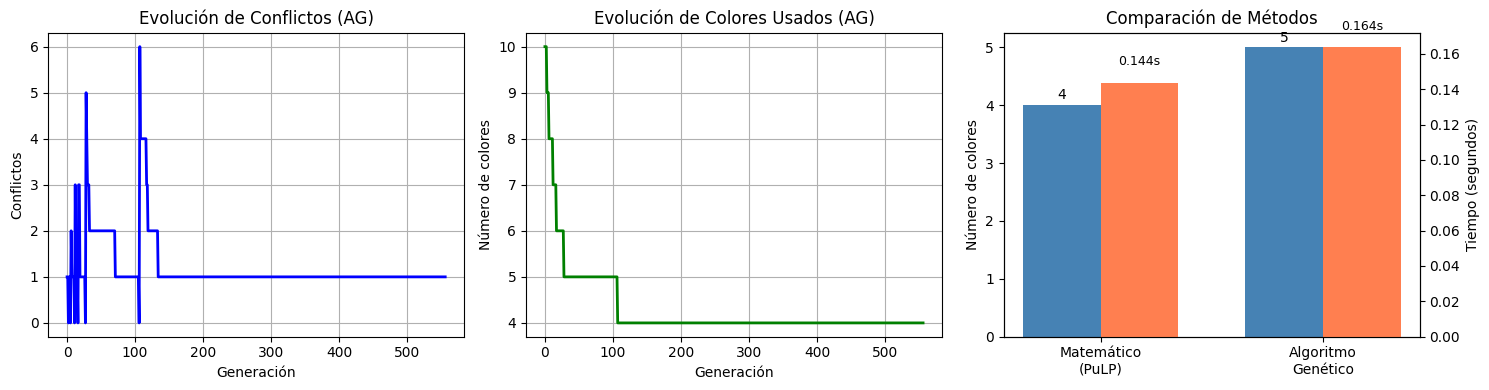


Gráfica guardada como 'resultados_coloracion.png'


In [18]:
"""
PROBLEMA DE COLORACIÓN DE GRAFOS
Objetivo: Encontrar el MÍNIMO número de colores (número cromático)
          tal que nodos adyacentes no tengan el mismo color

Algoritmo Genético + Método Matemático (PuLP)
Estudiante: [Tu nombre]
"""

import random
import time
import pulp
import matplotlib.pyplot as plt

# ============== DEFINICIÓN DEL GRAFO ==============
# Nodos del 1 al 19
V = list(range(1, 20))

# Aristas (basado en la imagen del grafo)
E = [
    (1, 2), (1, 4), (1, 16),
    (2, 3), (2, 4), (2, 5), (2, 6), (2, 7),
    (3, 7), (3, 11), (3, 19),
    (4, 5), (4, 8), (4, 9),
    (5, 6), (5, 9), (5, 10),
    (6, 7), (6, 10), (6, 14),
    (7, 11), (7, 14),
    (8, 9), (8, 12), (8, 16),
    (9, 10), (9, 12), (9, 13), (9, 15),
    (10, 13), (10, 14),
    (11, 14), (11, 19),
    (12, 15), (12, 16),
    (13, 14), (13, 15), (13, 17), (13, 18),
    (14, 18), (14, 19),
    (15, 16), (15, 17),
    (16, 17),
    (17, 18), (17, 19),
    (18, 19)
]

NUM_NODOS = len(V)
MAX_COLORES = NUM_NODOS  # Peor caso: cada nodo un color diferente

# ============== MÉTODO MATEMÁTICO CON PULP ==============
def metodo_matematico():
    """
    Busca el MÍNIMO número de colores usando programación lineal entera
    Estrategia: probar desde 1 color hasta encontrar solución factible
    """
    print("\n" + "="*50)
    print("MÉTODO MATEMÁTICO (PuLP)")
    print("="*50)
    
    inicio = time.time()
    
    # Probar desde 1 color hasta encontrar solución
    for num_colores in range(1, MAX_COLORES + 1):
        print(f"Probando con {num_colores} colores...", end=" ")
        
        # Crear el problema
        prob = pulp.LpProblem("Coloracion_Grafos", pulp.LpMinimize)
        
        # Variables: x[i][c] = 1 si nodo i tiene color c
        colores = range(1, num_colores + 1)
        x = {}
        for i in V:
            for c in colores:
                x[i, c] = pulp.LpVariable(f"x_{i}_{c}", cat='Binary')
        
        # Función objetivo: constante (solo buscamos factibilidad)
        prob += 0
        
        # Restricción 1: cada nodo tiene exactamente un color
        for i in V:
            prob += pulp.lpSum(x[i, c] for c in colores) == 1
        
        # Restricción 2: nodos adyacentes no pueden tener el mismo color
        for (i, j) in E:
            for c in colores:
                prob += x[i, c] + x[j, c] <= 1
        
        # Resolver
        prob.solve(pulp.PULP_CBC_CMD(msg=0))
        
        if prob.status == pulp.LpStatusOptimal:
            print("¡FACTIBLE!")
            
            fin = time.time()
            tiempo = fin - inicio
            
            # Extraer solución
            solucion = {}
            for i in V:
                for c in colores:
                    if pulp.value(x[i, c]) == 1:
                        solucion[i] = c
            
            print(f"\n*** NÚMERO CROMÁTICO ENCONTRADO: {num_colores} ***")
            print(f"Tiempo total: {tiempo:.4f} segundos")
            print(f"Asignación: {solucion}")
            
            return solucion, num_colores, tiempo
        else:
            print("No factible")
    
    return None, MAX_COLORES, time.time() - inicio


# ============== ALGORITMO GENÉTICO ==============
"""
PARÁMETROS DEL ALGORITMO GENÉTICO:
- Tipo de cromosoma: Lista de enteros (cada gen = color del nodo)
- Longitud: 19 genes (uno por nodo)
- Tamaño población: 50 individuos
- Inicialización: Aleatoria, empezando con muchos colores
- Criterio infactibilidad: Contar conflictos (aristas mismo color)
- Criterio de paro: 200 generaciones o fitness = 0
- Función fitness: Penaliza conflictos + número de colores usados
- Selección: Torneo de tamaño 3
- Probabilidad cruce: 0.8
- Puntos de cruce: 1 punto
- Probabilidad mutación: 0.15
- Reemplazo: Generacional con elitismo
"""

TAM_POBLACION = 80
GENERACIONES = 150
PROB_CRUCE = 0.8
PROB_MUTACION = 0.2
TAM_TORNEO = 3

def crear_individuo(num_colores):
    """Crea un cromosoma aleatorio con num_colores colores disponibles"""
    return [random.randint(1, num_colores) for _ in range(NUM_NODOS)]

def contar_conflictos(cromosoma):
    """Cuenta cuántas aristas tienen nodos del mismo color"""
    conflictos = 0
    for (i, j) in E:
        if cromosoma[i-1] == cromosoma[j-1]:
            conflictos += 1
    return conflictos

def contar_colores(cromosoma):
    """Cuenta cuántos colores diferentes se usan"""
    return len(set(cromosoma))

def calcular_fitness(cromosoma):
    """
    Fitness combinado:
    - Penalización alta por conflictos (x1000)
    - Penalización baja por número de colores
    Menor fitness = mejor solución
    """
    conflictos = contar_conflictos(cromosoma)
    colores = contar_colores(cromosoma)
    return conflictos * 1000 + colores

def seleccion_torneo(poblacion, fitnesses):
    """Selección por torneo"""
    participantes = random.sample(range(len(poblacion)), TAM_TORNEO)
    mejor = min(participantes, key=lambda i: fitnesses[i])
    return poblacion[mejor].copy()

def cruce(padre1, padre2):
    """Cruce de un punto"""
    if random.random() < PROB_CRUCE:
        punto = random.randint(1, NUM_NODOS - 1)
        hijo1 = padre1[:punto] + padre2[punto:]
        hijo2 = padre2[:punto] + padre1[punto:]
        return hijo1, hijo2
    return padre1.copy(), padre2.copy()

def mutacion(cromosoma, num_colores):
    """Mutación: cambiar color de un gen aleatorio"""
    for i in range(len(cromosoma)):
        if random.random() < PROB_MUTACION:
            cromosoma[i] = random.randint(1, num_colores)
    return cromosoma

def reducir_colores(cromosoma):
    """
    Renumera los colores para eliminar huecos
    Ej: [1,3,5,3,1] -> [1,2,3,2,1]
    """
    colores_usados = sorted(set(cromosoma))
    mapeo = {c: i+1 for i, c in enumerate(colores_usados)}
    return [mapeo[c] for c in cromosoma]

def algoritmo_genetico():
    """
    Ejecuta el algoritmo genético para encontrar el número cromático mínimo
    Estrategia: empezar con muchos colores e ir reduciendo progresivamente
    """
    print("\n" + "="*50)
    print("ALGORITMO GENÉTICO")
    print("="*50)
    
    inicio = time.time()
    
    # Guardar historial
    historial_mejor = []
    historial_colores = []
    
    mejor_solucion_global = None
    mejor_colores_global = NUM_NODOS
    
    # ESTRATEGIA: Probar con cada número de colores, de mayor a menor
    # Empezamos con 10 colores (suficiente para este grafo)
    
    for num_colores_actual in range(10, 0, -1):
        print(f"\nProbando con {num_colores_actual} colores...")
        
        # Más generaciones para números pequeños de colores (más difícil)
        gen_actuales = GENERACIONES if num_colores_actual > 5 else GENERACIONES * 3
        
        # Inicialización de población para este número de colores
        poblacion = [crear_individuo(num_colores_actual) for _ in range(TAM_POBLACION)]
        
        mejor_individuo = None
        mejor_conflictos = float('inf')
        
        # Correr generaciones para este número de colores
        for gen in range(gen_actuales):
            fitnesses = [contar_conflictos(ind) for ind in poblacion]
            
            # Actualizar mejor
            idx_mejor = fitnesses.index(min(fitnesses))
            if fitnesses[idx_mejor] < mejor_conflictos:
                mejor_conflictos = fitnesses[idx_mejor]
                mejor_individuo = poblacion[idx_mejor].copy()
            
            # Guardar historial
            historial_mejor.append(mejor_conflictos)
            historial_colores.append(num_colores_actual)
            
            # Si encontramos solución sin conflictos, éxito!
            if mejor_conflictos == 0:
                break
            
            # Crear nueva población
            nueva_poblacion = []
            
            # Elitismo
            nueva_poblacion.append(mejor_individuo.copy())
            
            while len(nueva_poblacion) < TAM_POBLACION:
                padre1 = seleccion_torneo(poblacion, fitnesses)
                padre2 = seleccion_torneo(poblacion, fitnesses)
                
                hijo1, hijo2 = cruce(padre1, padre2)
                
                hijo1 = mutacion(hijo1, num_colores_actual)
                hijo2 = mutacion(hijo2, num_colores_actual)
                
                nueva_poblacion.append(hijo1)
                if len(nueva_poblacion) < TAM_POBLACION:
                    nueva_poblacion.append(hijo2)
            
            poblacion = nueva_poblacion
        
        # Verificar si encontramos solución válida con este número de colores
        if mejor_conflictos == 0:
            print(f"  ¡FACTIBLE! Conflictos=0")
            mejor_solucion_global = mejor_individuo.copy()
            mejor_colores_global = num_colores_actual
            # Seguir intentando con menos colores
        else:
            print(f"  No factible (mejor conflictos={mejor_conflictos})")
            # No se puede con menos colores, terminar
            break
    
    fin = time.time()
    tiempo = fin - inicio
    
    # Usar la mejor solución encontrada
    if mejor_solucion_global is not None:
        mejor_individuo = reducir_colores(mejor_solucion_global)
        solucion = {i+1: mejor_individuo[i] for i in range(NUM_NODOS)}
        num_colores = contar_colores(mejor_individuo)
        conflictos = 0
    else:
        solucion = {i+1: i+1 for i in range(NUM_NODOS)}
        num_colores = NUM_NODOS
        conflictos = 0
    
    print(f"\n*** NÚMERO CROMÁTICO ENCONTRADO: {num_colores} ***")
    print(f"Conflictos: {conflictos}")
    print(f"Tiempo: {tiempo:.4f} segundos")
    print(f"Asignación: {solucion}")
    
    return solucion, num_colores, tiempo, historial_mejor, historial_colores, conflictos


# ============== EJEMPLO PASO A PASO ==============
def ejemplo_paso_a_paso():
    """Muestra un ejemplo MUY detallado con un mini-grafo de 6 nodos"""
    print("\n" + "="*70)
    print("EJEMPLO PASO A PASO (MINI-GRAFO DE 6 NODOS)")
    print("="*70)
    
    # Fijar semilla para reproducibilidad
    random.seed(123)
    
    # Mini-grafo de 6 nodos
    mini_nodos = 6
    mini_colores = 6
    mini_aristas = [
        (1, 2), (1, 3),
        (2, 3), (2, 4),
        (3, 4), (3, 5),
        (4, 5), (4, 6),
        (5, 6)
    ]
    
    print(f"\nMINI-GRAFO DE EJEMPLO:")
    print(f"  Nodos: 1, 2, 3, 4, 5, 6")
    print(f"  Aristas: {mini_aristas}")
    print(f"  Colores disponibles: 1, 2, 3, 4, 5, 6")
    print("""
       (1)---(2)
        |\\   /|
        | \\ / |
        |  X  |
        | / \\ |
        |/   \\|
       (3)---(4)
        |\\   /|
        | \\ / |
        |  X  |
        | / \\ |
        |/   \\|
       (5)---(6)
    """)
    
    def contar_conflictos_mini(cromosoma):
        conflictos = 0
        for (n1, n2) in mini_aristas:
            if cromosoma[n1-1] == cromosoma[n2-1]:
                conflictos += 1
        return conflictos
    
    # ========== PASO 1: CREAR POBLACIÓN INICIAL ==========
    print("-"*70)
    print("PASO 1: CREAR POBLACIÓN INICIAL")
    print("-"*70)
    print(f"Parámetros:")
    print(f"  - Tamaño población: 3 individuos")
    print(f"  - Genes por individuo: {mini_nodos}")
    print(f"  - Cada gen = color aleatorio entre 1 y {mini_colores}")
    
    mini_pop = []
    for i in range(3):
        print(f"\n  INDIVIDUO {i+1}:")
        cromosoma = []
        for gen in range(mini_nodos):
            color = random.randint(1, mini_colores)
            print(f"    Gen {gen+1} (nodo {gen+1}): random.randint(1,6) = {color}")
            cromosoma.append(color)
        print(f"    Cromosoma final: {cromosoma}")
        mini_pop.append(cromosoma)
    
    print(f"\n  POBLACIÓN INICIAL COMPLETA:")
    for i, ind in enumerate(mini_pop):
        print(f"    Individuo {i+1}: {ind}")
    
    # ========== PASO 2: CALCULAR FITNESS ==========
    print("\n" + "-"*70)
    print("PASO 2: CALCULAR FITNESS (contar conflictos)")
    print("-"*70)
    print("Regla: Si dos nodos conectados tienen el MISMO color → CONFLICTO")
    
    fitnesses = []
    for i, ind in enumerate(mini_pop):
        print(f"\n  INDIVIDUO {i+1}: {ind}")
        print(f"  Revisando cada arista:")
        conflictos = 0
        for (n1, n2) in mini_aristas:
            color1 = ind[n1-1]
            color2 = ind[n2-1]
            if color1 == color2:
                conflictos += 1
                print(f"    Arista ({n1},{n2}): color[{n1}]={color1}, color[{n2}]={color2} → ⚠️ CONFLICTO")
            else:
                print(f"    Arista ({n1},{n2}): color[{n1}]={color1}, color[{n2}]={color2} → ✓ OK")
        print(f"  FITNESS = {conflictos} conflictos")
        fitnesses.append(conflictos)
    
    print(f"\n  RESUMEN DE FITNESS:")
    for i, f in enumerate(fitnesses):
        print(f"    Individuo {i+1}: {f} conflictos")
    mejor_idx = fitnesses.index(min(fitnesses))
    print(f"  → Mejor individuo: {mejor_idx+1} con {fitnesses[mejor_idx]} conflictos")
    
    # ========== PASO 3: SELECCIÓN POR TORNEO ==========
    print("\n" + "-"*70)
    print("PASO 3: SELECCIÓN POR TORNEO")
    print("-"*70)
    print("Método: Elegir 3 al azar, gana el de MENOR fitness")
    
    # Padre 1
    print(f"\n  SELECCIONAR PADRE 1:")
    participantes1 = random.sample(range(3), 3)
    print(f"    random.sample([0,1,2], 3) = {participantes1}")
    print(f"    Participantes: Individuos {[p+1 for p in participantes1]}")
    print(f"    Sus fitness: {[fitnesses[p] for p in participantes1]}")
    ganador1 = min(participantes1, key=lambda x: fitnesses[x])
    print(f"    Menor fitness: {fitnesses[ganador1]}")
    print(f"    GANADOR: Individuo {ganador1+1}")
    padre1 = mini_pop[ganador1].copy()
    print(f"    Padre 1 = {padre1}")
    
    # Padre 2
    print(f"\n  SELECCIONAR PADRE 2:")
    participantes2 = random.sample(range(3), 3)
    print(f"    random.sample([0,1,2], 3) = {participantes2}")
    print(f"    Participantes: Individuos {[p+1 for p in participantes2]}")
    print(f"    Sus fitness: {[fitnesses[p] for p in participantes2]}")
    ganador2 = min(participantes2, key=lambda x: fitnesses[x])
    print(f"    Menor fitness: {fitnesses[ganador2]}")
    print(f"    GANADOR: Individuo {ganador2+1}")
    padre2 = mini_pop[ganador2].copy()
    print(f"    Padre 2 = {padre2}")
    
    # ========== PASO 4: CRUCE ==========
    print("\n" + "-"*70)
    print("PASO 4: CRUCE DE UN PUNTO")
    print("-"*70)
    print(f"Probabilidad de cruce: {PROB_CRUCE} (80%)")
    
    rand_cruce = random.random()
    print(f"\n  random.random() = {rand_cruce:.4f}")
    
    if rand_cruce < PROB_CRUCE:
        print(f"  {rand_cruce:.4f} < {PROB_CRUCE} → ¡SÍ HAY CRUCE!")
        
        punto = random.randint(1, mini_nodos - 1)
        print(f"\n  Punto de cruce: random.randint(1, 5) = {punto}")
        
        print(f"\n  Padre 1: {padre1}")
        print(f"           ", end="")
        for i in range(mini_nodos):
            if i == punto:
                print("↑ ", end="")
            else:
                print("  ", end="")
        print("← punto de corte")
        print(f"  Padre 2: {padre2}")
        
        hijo1 = padre1[:punto] + padre2[punto:]
        hijo2 = padre2[:punto] + padre1[punto:]
        
        print(f"\n  HIJO 1 = Padre1[0:{punto}] + Padre2[{punto}:{mini_nodos}]")
        print(f"         = {padre1[:punto]} + {padre2[punto:]}")
        print(f"         = {hijo1}")
        
        print(f"\n  HIJO 2 = Padre2[0:{punto}] + Padre1[{punto}:{mini_nodos}]")
        print(f"         = {padre2[:punto]} + {padre1[punto:]}")
        print(f"         = {hijo2}")
    else:
        print(f"  {rand_cruce:.4f} >= {PROB_CRUCE} → NO HAY CRUCE")
        hijo1 = padre1.copy()
        hijo2 = padre2.copy()
        print(f"  Hijo 1 = copia de Padre 1 = {hijo1}")
        print(f"  Hijo 2 = copia de Padre 2 = {hijo2}")
    
    # ========== PASO 5: MUTACIÓN ==========
    print("\n" + "-"*70)
    print("PASO 5: MUTACIÓN")
    print("-"*70)
    print(f"Probabilidad de mutación por gen: {PROB_MUTACION} (20%)")
    print("Regla: Para cada gen, si random() < 0.2 → cambiar a color aleatorio")
    
    print(f"\n  MUTANDO HIJO 1: {hijo1}")
    hijo1_antes = hijo1.copy()
    
    print(f"\n  {'Gen':<5} {'Valor':<7} {'Random':<10} {'¿Muta?':<8} {'Nuevo':<7}")
    print(f"  {'-'*40}")
    
    for i in range(mini_nodos):
        rand_mut = random.random()
        valor_antes = hijo1[i]
        
        if rand_mut < PROB_MUTACION:
            nuevo = random.randint(1, mini_colores)
            hijo1[i] = nuevo
            print(f"  {i+1:<5} {valor_antes:<7} {rand_mut:<10.4f} {'SÍ':<8} {nuevo:<7} ← ¡MUTÓ!")
        else:
            print(f"  {i+1:<5} {valor_antes:<7} {rand_mut:<10.4f} {'NO':<8} {valor_antes:<7}")
    
    print(f"\n  Hijo 1 ANTES:   {hijo1_antes}")
    print(f"  Hijo 1 DESPUÉS: {hijo1}")
    cambios = sum(1 for a, b in zip(hijo1_antes, hijo1) if a != b)
    print(f"  Genes mutados: {cambios}")
    
    # ========== PASO 6: EVALUAR HIJO ==========
    print("\n" + "-"*70)
    print("PASO 6: EVALUAR NUEVO INDIVIDUO")
    print("-"*70)
    
    print(f"\n  Hijo 1 final: {hijo1}")
    print(f"\n  Verificando conflictos:")
    
    conflictos_hijo = 0
    for (n1, n2) in mini_aristas:
        color1 = hijo1[n1-1]
        color2 = hijo1[n2-1]
        if color1 == color2:
            conflictos_hijo += 1
            print(f"    Arista ({n1},{n2}): color[{n1}]={color1}, color[{n2}]={color2} → ⚠️ CONFLICTO")
        else:
            print(f"    Arista ({n1},{n2}): color[{n1}]={color1}, color[{n2}]={color2} → ✓ OK")
    
    print(f"\n  RESULTADO:")
    print(f"    Conflictos: {conflictos_hijo}")
    print(f"    Colores usados: {sorted(set(hijo1))}")
    
    if conflictos_hijo == 0:
        print(f"    ¡SOLUCIÓN VÁLIDA! No hay conflictos")
    else:
        print(f"    Solución inválida, hay {conflictos_hijo} conflictos")
    
    # ========== PASO 7: REEMPLAZO ==========
    print("\n" + "-"*70)
    print("PASO 7: REEMPLAZO CON ELITISMO")
    print("-"*70)
    print("Regla: El MEJOR de la generación anterior pasa directo (élite)")
    
    print(f"\n  Mejor de generación anterior: Individuo {mejor_idx+1}")
    print(f"  Su cromosoma: {mini_pop[mejor_idx]}")
    print(f"  Su fitness: {fitnesses[mejor_idx]} conflictos")
    
    print(f"\n  NUEVA POBLACIÓN:")
    print(f"    Pos 1: {mini_pop[mejor_idx]} ← ÉLITE (el mejor anterior)")
    print(f"    Pos 2: {hijo1} ← Hijo 1 (nuevo)")
    print(f"    Pos 3: {hijo2} ← Hijo 2 (nuevo)")
    
    # ========== RESUMEN ==========
    print("\n" + "="*70)
    print("RESUMEN DE LA GENERACIÓN")
    print("="*70)
    print(f"  Mejor fitness generación anterior: {min(fitnesses)}")
    print(f"  Fitness del Hijo 1: {conflictos_hijo}")
    
    if conflictos_hijo < min(fitnesses):
        print(f"  → ¡MEJORA! El hijo es mejor")
    elif conflictos_hijo == min(fitnesses):
        print(f"  → IGUAL: Mismo fitness que el mejor")
    else:
        print(f"  → SIN MEJORA: El hijo es peor, pero el élite se conserva")
    
    print(f"\n  El algoritmo repite estos pasos hasta:")
    print(f"    - Encontrar solución con 0 conflictos, O")
    print(f"    - Llegar al máximo de generaciones")


# ============== VISUALIZACIÓN ==============
def graficar_resultados(hist_conflictos, hist_colores, t_mat, t_ag, col_mat, col_ag):
    """Genera gráficas de comparación"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Gráfica 1: Evolución de conflictos
    axes[0].plot(hist_conflictos, 'b-', linewidth=2)
    axes[0].set_xlabel('Generación')
    axes[0].set_ylabel('Conflictos')
    axes[0].set_title('Evolución de Conflictos (AG)')
    axes[0].grid(True)
    
    # Gráfica 2: Evolución de colores
    axes[1].plot(hist_colores, 'g-', linewidth=2)
    axes[1].set_xlabel('Generación')
    axes[1].set_ylabel('Número de colores')
    axes[1].set_title('Evolución de Colores Usados (AG)')
    axes[1].grid(True)
    
    # Gráfica 3: Comparación final
    metodos = ['Matemático\n(PuLP)', 'Algoritmo\nGenético']
    colores_final = [col_mat, col_ag]
    tiempos = [t_mat, t_ag]
    
    x = range(len(metodos))
    width = 0.35
    
    bars1 = axes[2].bar([i - width/2 for i in x], colores_final, width, label='Colores', color='steelblue')
    axes[2].set_ylabel('Número de colores')
    axes[2].set_title('Comparación de Métodos')
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(metodos)
    
    ax2 = axes[2].twinx()
    bars2 = ax2.bar([i + width/2 for i in x], tiempos, width, label='Tiempo', color='coral')
    ax2.set_ylabel('Tiempo (segundos)')
    
    # Etiquetas
    for bar, val in zip(bars1, colores_final):
        axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                    str(val), ha='center', fontsize=10)
    for bar, val in zip(bars2, tiempos):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{val:.3f}s', ha='center', fontsize=9)
    
    plt.tight_layout()
    plt.savefig('resultados_coloracion.png', dpi=150)
    plt.show()
    print("\nGráfica guardada como 'resultados_coloracion.png'")


def imprimir_tabla(sol_mat, col_mat, t_mat, sol_ag, col_ag, t_ag, conf_ag):
    """Imprime tabla de comparación"""
    print("\n" + "="*65)
    print("TABLA DE COMPARACIÓN DE RESULTADOS")
    print("="*65)
    print(f"{'Criterio':<30} {'Matemático':<15} {'Genético':<15}")
    print("-"*65)
    print(f"{'Número cromático (χ)':<30} {col_mat:<15} {col_ag:<15}")
    print(f"{'Conflictos':<30} {0:<15} {conf_ag:<15}")
    print(f"{'Tiempo (segundos)':<30} {t_mat:<15.4f} {t_ag:<15.4f}")
    print(f"{'Solución óptima':<30} {'Sí':<15} {'Sí' if conf_ag == 0 else 'No':<15}")
    print("="*65)
    
    print("\n" + "="*65)
    print("ASIGNACIÓN DE COLORES POR NODO")
    print("="*65)
    print(f"{'Nodo':<8} {'Matemático':<15} {'Genético':<15}")
    print("-"*65)
    for nodo in V:
        print(f"{nodo:<8} {sol_mat[nodo]:<15} {sol_ag[nodo]:<15}")
    print("="*65)


# ============== PROGRAMA PRINCIPAL ==============
if __name__ == "__main__":
    print("="*65)
    print("PROBLEMA DE COLORACIÓN DE GRAFOS")
    print("Objetivo: Encontrar el MÍNIMO número de colores (χ)")
    print(f"Grafo: {NUM_NODOS} nodos, {len(E)} aristas")
    print("="*65)
    
    # Ejemplo paso a paso
    ejemplo_paso_a_paso()
    
    # Método matemático
    sol_mat, col_mat, t_mat = metodo_matematico()
    
    # Algoritmo genético
    sol_ag, col_ag, t_ag, hist_conf, hist_col, conf_ag = algoritmo_genetico()
    
    # Tabla de comparación
    imprimir_tabla(sol_mat, col_mat, t_mat, sol_ag, col_ag, t_ag, conf_ag)
    
    # Gráficas
    graficar_resultados(hist_conf, hist_col, t_mat, t_ag, col_mat, col_ag)